<font face="B Mitra" size=4>
<div dir=rtl align=center>
<br>
<img src="https://aut.ac.ir/templates/tmpl_modern01/images/logo_fa.png" alt="Amirkabir University Logo" width="100">
<br>
<font size=5> دانشگاه صنعتی امیرکبیر
(پلی تکنیک تهران)
<br>
<font size=5> دانشکده ریاضی و علوم کامپیوتر
<br>
<font size=6>
<b>پروژه دوم داده کاوی</b>
<br>
<font size=5> استاد درس: دکتر فاطمه شاکری
<br>
<font size=5> طراحان پروژه: روژان واصف، رها کریمی نیا،محدثه مقدم
<br>
<font size=4> بهار ۱۴۰۵
<hr>

<div dir=rtl>
<font face="B Nazanin" size=4>
در هر بخش، توضیحات مربوط داده شده و سپس سوالاتی با <font color="#ffcc00">رنگ زرد</font> پرسیده شده است. شما باید به این سوالات در گزارش‌کار پاسخ دهید و سلول‌های کد خواسته‌شده را کامل کنید. انتظار می‌رود در انتها، با اجرای دستور Run All تمامی سلول‌های کد به درستی اجرا شوند و نتایج مطلوب را خروجی دهند.
<div dir=rtl>
شما مجاز به استفاده از کتاب‌خانه‌های دیگری به‌جز موارد import شده در سلول زیر نیستید.
</font>
</p>

In [1]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.feature_selection import mutual_info_classif
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import roc_curve, auc

import warnings
warnings.filterwarnings('ignore')


<div dir=rtl>
<h2>
<font face="B Nazanin" color=#0099cc>
بارگذاری مجموعه داده

<div dir=rtl>
<font face="B Nazanin" size=4>
دستور
`pd.read_csv("your_dataset_file.csv")`
 داده‌های جدول فایل مشخص‌شده را به‌صورت یک متغیرِ دیتافریم از کتاب‌خانه pandas برمی‌گرداند. با ذخیره‌سازی این دیتافریم می‌توانید در محیط پایتون و نوت‌بوک از آن استفاده کنید.
</font>
</p>

In [2]:

df = pd.read_csv("../data/loan_approval.csv")

<div dir=rtl>
<h1>
<font face="B Nazanin" color=#0099cc>
    تحلیل اکتشافی داده ها(EDA)
    و 
پیش‌پردازش داده (Preprocessing)
 </font>
<br>
<font face="B Nazanin" size=4>
    تحلیل اکتشافی داده (Exploratory Data Analysis), فرآیند شناخت و درک عمیق داده‌ها پیش از مدل‌سازی است. در این مرحله هدف آن است که ساختار داده‌ها، توزیع ویژگی‌ها، روابط میان آن‌ها و مشکلات احتمالی موجود در داده شناسایی شوند. EDA به دو روش آماری و بصری انجام می‌شود.
<br>
پیش‌پردازش داده مرحله‌ای است که در آن داده‌های خام را برای ورود به مدل‌های یادگیری ماشین آماده می‌کنیم. این دو مرحله مکمل یکدیگرند — آنچه در تحلیل اکتشافی کشف می‌شود، در پیش‌پردازش اصلاح و بهبود می‌یابد.

<div dir=rtl>
<h1>
<font face="B Nazanin" color=#0099cc>
EDA آماری
</font>
<br>
<font face="B Nazanin" size=4>
EDA آماری با استفاده از توابع و معیارهای آماری، ساختار و خصوصیات کمّی داده‌ها را بررسی می‌کند. 

<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-دستور `()df.head` 
<div dir=rtl>
</font>
<font face="B Nazanin" size=4 >
دستور `()df.head` مقادیر ۵ سطر اول دیتافریم df را نمایش می‌دهد. از این دستور استفاده کنید تا ۵ رکورد اول به همراه تمامی ویژگی‌های مجموعه داده را در خروجی ببینید.

</p>

In [3]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000.0,12,778,2400000.0,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000.0,8,417,2700000.0,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000.0,20,506,7100000.0,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000.0,8,467,18200000.0,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000.0,20,382,12400000.0,8200000,29400000,5000000,Rejected


<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-دستور `df.shape` 
<div dir=rtl>
</font>
<font face="B Nazanin" size=4 >
با استفاده از دستور `df.shape` می‌توانید ابعاد مجموعه داده را مشاهده کنید.
مجموعه داده این پروژه ۱۳ ستون و ۴۲۷۹ سطر دارد، مطمئن شوید که مجموعه داده را به درستی بارگذاری کردید.
</p>

In [4]:
df.shape

(4279, 13)

<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-دستور '()df.info'
<div dir=rtl>
</font>
<font face="B Nazanin" size=4 >
دستور ()df.info اطلاعات کلی دیتافریم شامل تعداد سطرها، نام ستون‌ها، نوع داده هر ستون و تعداد مقادیر غیرنال را نمایش می‌دهد. از این دستور استفاده کنید تا نمای کلی از ساختار مجموعه داده به دست آورید
.
</p>

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4279 entries, 0 to 4278
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   loan_id                   4279 non-null   int64  
 1   no_of_dependents          4279 non-null   int64  
 2   education                 4279 non-null   str    
 3   self_employed             4150 non-null   str    
 4   income_annum              4279 non-null   int64  
 5   loan_amount               3928 non-null   float64
 6   loan_term                 4279 non-null   int64  
 7   cibil_score               4279 non-null   int64  
 8   residential_assets_value  4021 non-null   float64
 9   commercial_assets_value   4279 non-null   int64  
 10  luxury_assets_value       4279 non-null   int64  
 11  bank_asset_value          4279 non-null   int64  
 12  loan_status               4279 non-null   str    
dtypes: float64(2), int64(8), str(3)
memory usage: 434.7 KB


<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-دستور '()df.describe'
<div dir=rtl>
</font>
<font face="B Nazanin" size=4 >
دستور ()df.describe آمار توصیفی ستون‌های عددی شامل میانگین، انحراف معیار، مینیمم، ماکزیمم و چارک‌ها را نمایش می‌دهد. از این دستور استفاده کنید تا توزیع و دامنه مقادیر هر ویژگی عددی را بررسی کنید.

</p>

In [6]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4279.000000,4279.000000,4.279000e+03,3.928000e+03,4279.000000,4279.000000,4.021000e+03,4.279000e+03,4.279000e+03,4.279000e+03
mean,2134.562515,2.500351,5.059547e+06,1.519646e+07,10.903950,599.896705,7.441507e+06,4.977401e+06,1.512744e+07,4.979692e+06
std,1232.098421,1.695341,2.804954e+06,9.056741e+06,5.705724,172.297707,6.496085e+06,4.391024e+06,9.098122e+06,3.248077e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,0.000000e+00,0.000000e+00,3.000000e+05,0.000000e+00
25%,1069.500000,1.000000,2.700000e+06,7.775000e+06,6.000000,453.500000,2.100000e+06,1.300000e+06,7.500000e+06,2.400000e+06
50%,2133.000000,3.000000,5.100000e+06,1.460000e+07,10.000000,600.000000,5.500000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.500000,4.000000,7.500000e+06,2.160000e+07,16.000000,747.000000,1.130000e+07,7.650000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-دستور '()value_counts'
<div dir=rtl>
</font>
<font face="B Nazanin" size=4>
دستور ()value_counts تعداد تکرار هر مقدار منحصربه‌فرد در یک ستون را نمایش می‌دهد. از این دستور استفاده کنید تا توزیع کلاس‌های ستون هدف را بررسی کنید.

</p>

In [7]:
print(df['loan_status'].value_counts())

loan_status
Approved    2662
Rejected    1617
Name: count, dtype: int64


<div dir=rtl>
<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-حذف داده‌های اضافی
<div dir=rtl>
</font>
<font face="B Nazanin" size=4>
دستور `()df.duplicated` رکورد (سطر) های تکراری را پیدا می‌کند و با اجرای تابع `()sum` می‌توانید تعداد رکوردهای تکراری را پیدا کنید.
</p>
با اجرای دستور `()df.drop_duplicates` یک دیتافریم جدید بدون رکوردهای تکراری ساخته می‌شود.
</p>
در صورت وجود رکوردهای تکراری، آن‌ها را حذف کنید.


</p>

In [8]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Duplicate rows: 10
Shape after removing duplicates: (4269, 13)


<div dir=rtl>
<font face="B Nazanin" size=4>
در این مجموعه داده، ویژگی `loan_id` ارزشی ندارد.
</p>
با تابع `df.drop("column_name", axis=1)` می‌توانید ستون `column_name` را حذف کنید.
</p>
 پارامتر `axis` دو مقدار `0` برای سطرها و `1` برای ستون‌ها دارد.

</font>
</p>

In [9]:
df = df.drop("loan_id", axis=1)
print("Shape after dropping loan_id:", df.shape)


Shape after dropping loan_id: (4269, 12)


<div dir=rtl>
<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-پردازش مقادیر گمشده
<div dir=rtl>
</font>
<font face="B Nazanin" size=4>
هر مجموعه داده ممکن است دارای مقادیر گم‌شده باشد.
</p>
با استفاده از تابع '()isna.()sum' می‌توان تعداد مقادیر گمشده هر ستون را مشاهده کرد.
</p>
    برای جایگزینی مقدار گم‌شده یک ویژگی یک سطر، می‌توانید میانگین، مد و... آن ستون را قرار دهید. در صورت تعداد زیاد مقادیر گم‌شده یک رکورد و یا یک ویژگی، می‌توانیم آن را به کل حذف کنیم.
    پس ابتدا تعداد مقادیر گمشده دیتاست را بررسی کنید و سپس آن ها را با روش مناسب جایگزین کنید.

</p>

In [10]:
print("Missing values per column:")
print(df.isna().sum())


Missing values per column:
no_of_dependents              0
education                     0
self_employed               128
income_annum                  0
loan_amount                 341
loan_term                     0
cibil_score                   0
residential_assets_value    256
commercial_assets_value       0
luxury_assets_value           0
bank_asset_value              0
loan_status                   0
dtype: int64


In [11]:

df['loan_amount'] = df['loan_amount'].fillna(df['loan_amount'].median())
df['residential_assets_value'] = df['residential_assets_value'].fillna(df['residential_assets_value'].median())

df['self_employed'] = df['self_employed'].fillna(df['self_employed'].mode()[0])

print("Missing values after handling:")
print(df.isna().sum())

Missing values after handling:
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64


<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
    ۱.
    مقادیر گمشده هرکدام از ستون ها را به چه روشی جایگزین کردید؟علت را توضیح دهید.

<div dir="rtl" style="text-align: left; font-family: Tahoma, Arial; line-height: 1.5;">

ستون‌های <code>loan_amount</code> و <code>residential_assets_value</code> هر دو عددی هستند و طبق آنچه بالاتر به کمک دستور describe() دیدیم، توزیع چولگی مثبت (Right-skewed) دارند (بخاطر بزرگتر بودن میانگین نسبت به میانه)؛ یعنی تعدادی مقدار پرت (Outlier) مثل وام‌ها یا دارایی‌های خیلی بزرگ در آن‌ها وجود دارد. اگر برای پر کردن جای خالی این ستون‌ها از میانگین استفاده می‌کردیم، همین مقادیر پرت میانگین را به سمت خودشان می‌کشیدند و یک عدد غیرواقعی به‌دست می‌آمد. به همین دلیل از میانه (Median) استفاده شد، چون میانه فقط به مقدار وسط داده‌های مرتب‌شده وابسته است و نسبت به اعداد حدی مقاوم می‌ماند؛ پس نماینده‌ی قعی‌تری از مرکز داده در توزیع‌های چوله است.

<br>

ستون <code>self_employed</code> دسته‌ای است و فقط مقادیر Yes و No دارد و به همین دلیل گرفتن میانگین یا میانه بی‌معناست تنها معیار منطقی برای داده‌ی دسته‌ای مد (Mode) است. با جایگزینی مقادیر گم‌شده با فراوان‌ترین دسته، ساختار طبیعی توزیع داده حفظ می‌شود و کمترین اختلال در آن ایجاد می‌گردد.

</div>

<div dir=rtl>
<h1>
<font face="B Nazanin" color=#0099cc>
EDA بصری
<br>
</font>
<font face="B Nazanin" size=4>
 EDA بصری با استفاده از نمودارها و تصویرسازی، الگوها و روابط موجود در داده‌ها را به شکل قابل درک نمایش می‌دهد.

<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-هیستوگرام توزیع ویژگی‌های عددی 
<div dir=rtl>
</font>
<font face="B Nazanin" size=4>
نمودار
هیستوگرام, توزیع مقادیر یک ویژگی عددی را نمایش می‌دهد و به ما کمک می‌کند چولگی، دامنه و شکل توزیع داده‌ها را به صورت بصری درک کنیم.
</p>
هیستوگرام توزیع ویژگی‌های عددی مجموعه داده را رسم کنید.

</p>

Numerical features:
['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


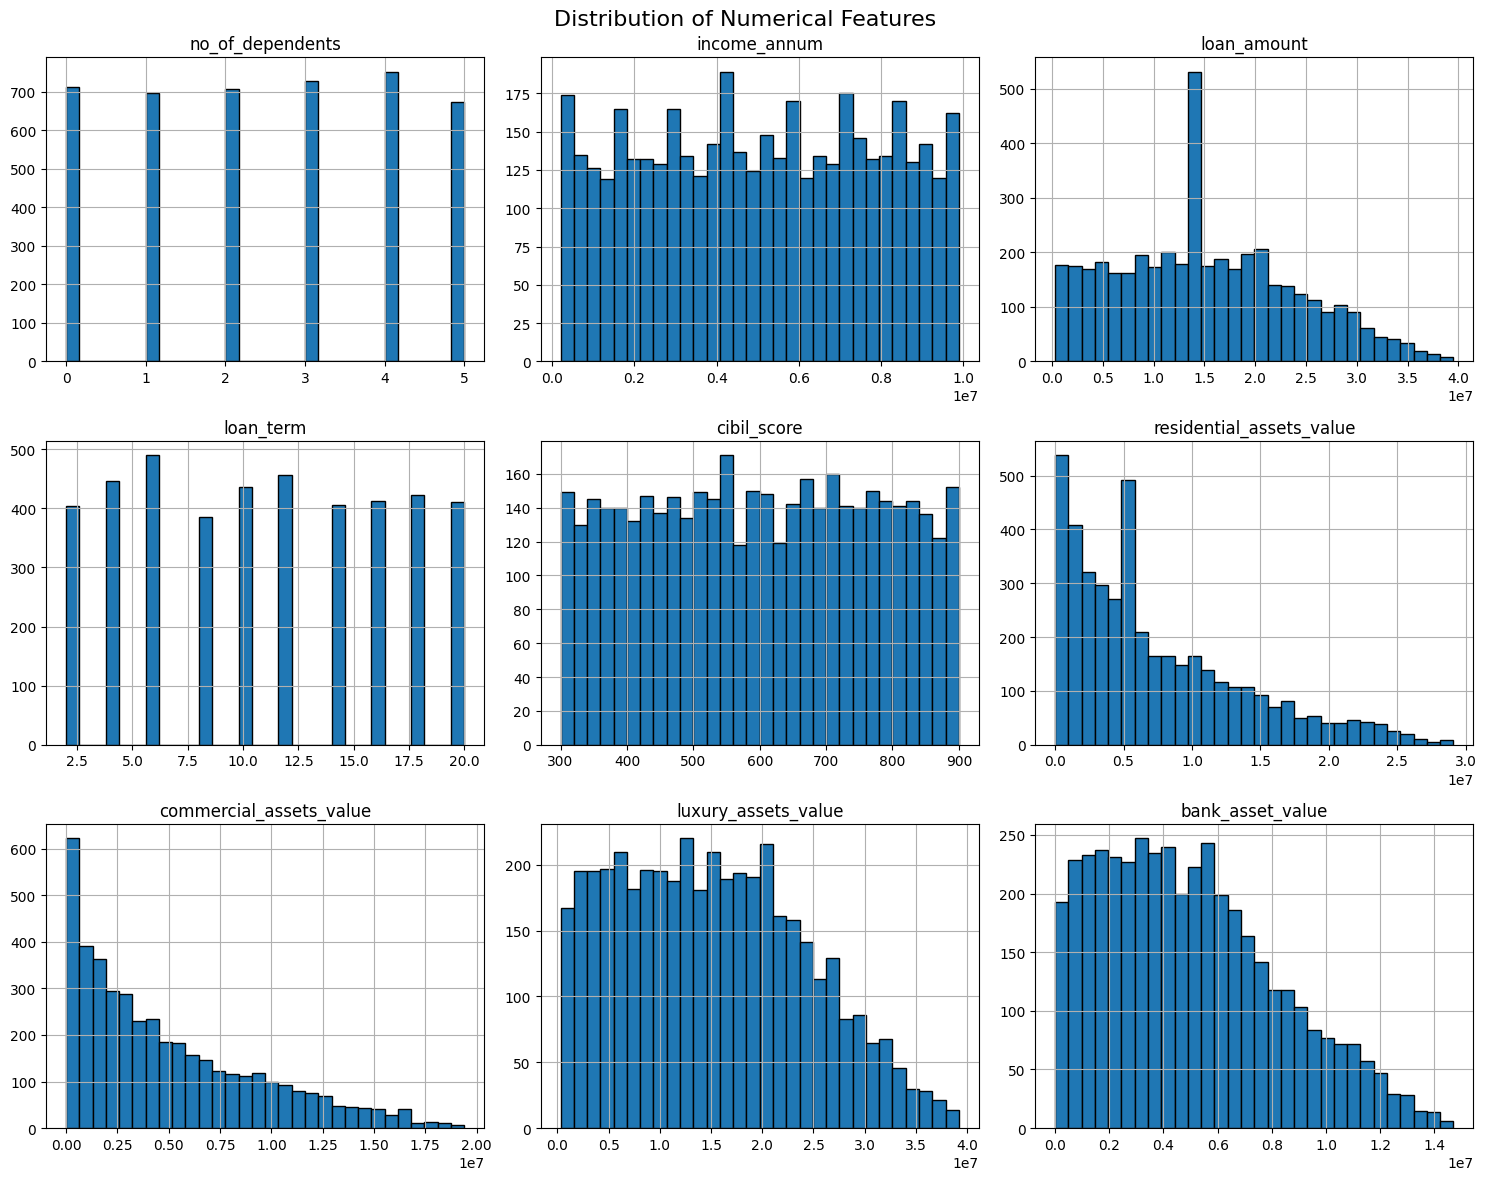

In [12]:

numerical_features = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical features:")
print(list(numerical_features))


df[numerical_features].hist(figsize=(15, 12), bins=30, edgecolor='black')

plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
    ۲.مفهوم چولگی (Skewness) را بررسی کنید. با توجه به هیستوگرام‌های رسم‌شده، توزیع کدام ویژگی‌ها چوله است و جهت چولگی آن‌ها به چه سمتی است؟

<div dir="rtl" style="text-align: right;">

چولگی (Skewness) معیاری برای سنجش میزان عدم تقارن توزیع داده‌ها حول مقدار میانگین است و نشان می‌دهد که توزیع یک متغیر تا چه اندازه از حالت متقارن فاصله گرفته و دنباله‌ی آن به کدام سمت کشیده شده است. در یک توزیع کاملاً متقارن مقدار چولگی برابر با صفر است اگر دنباله‌ی توزیع به سمت مقادیر بزرگ کشیده شود چولگی مثبت (Right-skewed) و اگر دنباله به سمت مقادیر کوچک کشیده شود چولگی منفی (Left-skewed) خواهد بود. در حالت چولگی مثبت، مقدار مد کوچک‌تر از میانه و میانه کوچک‌تر از میانگین است.

بر اساس هیستوگرام‌های رسم‌شده برای ویژگی‌های عددی دیتاست، سه ویژگی loan_amount ، residential_assets_value ، commercial_assets_value  دارای چولگی مثبت هستند و bank_assets_value و luxury_assets_value  هم چولگی راست اما چولگی کمتری دارند. در این ویژگی‌ها بخش عمده‌ی مشاهدات در بازه‌ی مقادیر پایین متمرکز شده و تنها تعداد محدودی مقدار بزرگ (Outlier) موجب کشیده‌شدن دنباله‌ی توزیع به سمت راست شده است.

</div>

<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-نمودار تعادل کلاس‌ها
<div dir=rtl>
</font>
<font face="B Nazanin" size=4>
نمودار تعادل کلاس‌ها تعداد نمونه‌های هر کلاس ستون هدف را نمایش می‌دهد و به ما کمک می‌کند عدم تعادل احتمالی میان کلاس‌ها را شناسایی کنیم.
</p>
نمودار تعادل کلاس‌های ستون هدف (loan_status) را رسم کنید.

</p>

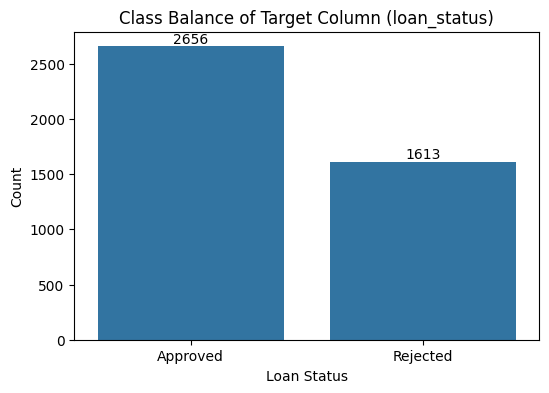

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

loan_status
Approved    62.215976
Rejected    37.784024
Name: proportion, dtype: float64


In [13]:

plt.figure(figsize=(6, 4))
sns.countplot(x='loan_status', data=df)
plt.title('Class Balance of Target Column (loan_status)')
plt.xlabel('Loan Status')
plt.ylabel('Count')


for container in plt.gca().containers:
    plt.gca().bar_label(container)

plt.show()


print(df['loan_status'].value_counts())
print()
print(df['loan_status'].value_counts(normalize=True) * 100)


<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-ماتریس همبستگی ویژگی‌های عددی (Correlation Heatmap of Numerical Features)
<div dir=rtl>
</font>
<font face="B Nazanin" size=4>
ماتریس همبستگی ,میزان رابطه خطی بین تمام ویژگی‌های عددی را به صورت یک نقشه حرارتی (Heatmap) رنگی نمایش می‌دهد و به ما کمک می‌کند بفهمیم کدام ویژگی‌ها با هم یا با ستون هدف (Target Column) رابطه قوی و کدام ها رابطه ضعیف دارند. هر خانه نشان‌دهنده ضریب همبستگی (Correlation Coefficient) بین دو ویژگی میباشد.
</p>
ماتریس همبستگی بین ویژگی‌های عددی مجموعه داده را به صورت هیت مپ رسم کنید.

</p>

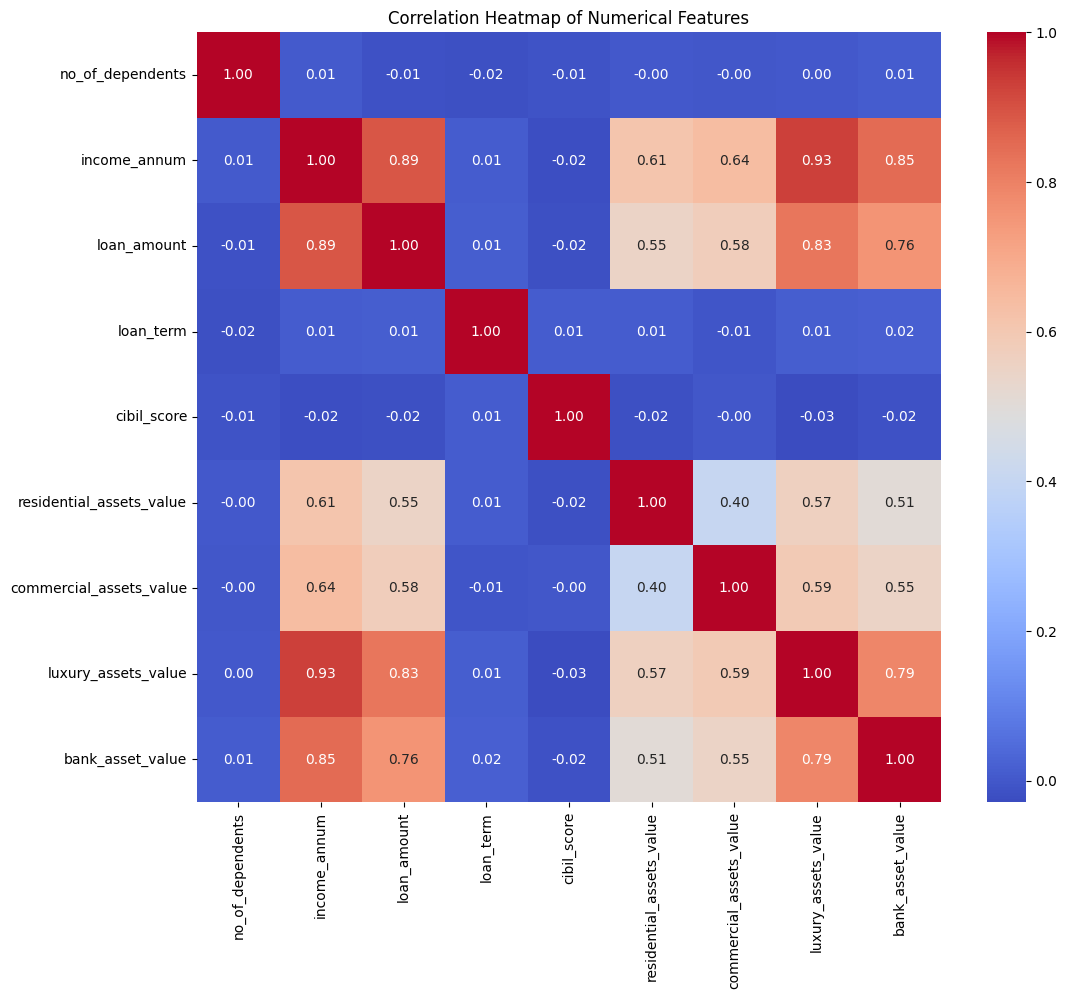

In [14]:

numerical_df = df.select_dtypes(include='number')
correlation_matrix = numerical_df.corr()
_
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
۳.
    فرمول محاسبه ضریب همبستگی پیرسون را بنویسید و توضیح دهید که در چه بازه‌ای قرار می‌گیرد. همچنین از روی Heatmap رسم‌شده، دو ویژگی که بیشترین همبستگی مثبت و دو ویژگی که بیشترین همبستگی منفی را با یکدیگر دارند، نام ببرید.



<div dir="rtl">

ضریب همبستگی پیرسون میزان و جهت رابطه‌ی خطی بین دو متغیر کمّی را اندازه‌گیری می‌کند و از فرمول زیر به دست می‌آید:

</div>

$$
r = \frac{\sum_{i=1}^{n}(X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum_{i=1}^{n}(X_i - \bar{X})^2}\;\sqrt{\sum_{i=1}^{n}(Y_i - \bar{Y})^2}} = \frac{\text{Cov}(X, Y)}{\sigma_X \, \sigma_Y}
$$

<div dir="rtl">

که در آن $X_i, Y_i$ مقدار $i$اُمین نمونه، $\bar{X}, \bar{Y}$ میانگین هر متغیر و $n$ تعداد نمونه‌هاست.

مقدار این ضریب همواره در بازه‌ی $-1 \leq r \leq +1$ قرار دارد:

- $r = +1$ : همبستگی مثبت کامل (با افزایش یک متغیر، دیگری به‌صورت خطی افزایش می‌یابد).
- $r = 0$ : نبودِ رابطه‌ی خطی میان دو متغیر.
- $r = -1$ : همبستگی منفی کامل (با افزایش یک متغیر، دیگری به‌صورت خطی کاهش می‌یابد).

 این ضریب تنها رابطه‌ی خطی را می‌سنجد بنابراین ممکن است دو متغیر رابطه‌ی غیرخطی قوی داشته باشند، اما مقدار $r$ نزدیک به صفر باشد.

 تحلیل نتایج Heatmap

ببر اساس ماتریس همبستگی رسم‌شده، قوی‌ترین همبستگی‌های مثبت بین ویژگی income_annum و دارایی‌ها دیده می‌شود؛ بیشترین مقدار مربوط به income_annum و luxury_assets_value با ضریب حدود ۰.۹۳ است که نشان می‌دهد افراد با درآمد سالانه‌ی بالاتر، دارایی‌های لوکس بیشتری دارند. همچنین همبستگی قوی (بالای ۰.۸) میان income_annum، loan_amount و سایر دارایی‌ها وجود دارد؛ این یعنی چند ویژگی عملاً اطلاعات مشابهی را منتقل می‌کنند و تا حد زیادی یکدیگر را تکرار می‌کنند.

در مقابل، ویژگی cibil_score همبستگی بسیار ضعیفی (نزدیک به صفر) با متغیرهای مالی دارد؛ یعنی امتیاز اعتباری مستقل از میزان درآمد و دارایی است و اطلاعاتی متفاوت به مدل اضافه می‌کند.

</div>


<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
- نمودار جعبه‌ای ویژگی‌های عددی (Box Plot of Numerical Features)
<div dir=rtl>
</font>
<font face="B Nazanin" size=4>
 نمودار جعبه‌ای , توزیع مقادیر یک ویژگی عددی را به صورت فشرده نمایش می‌دهد و به ما کمک می‌کند میانه (Median)، چارک‌ها (Quartiles) و مقادیر پرت (Outliers) را به راحتی شناسایی کنیم. این نمودار به خصوص برای درک وجود یا عدم وجود داده‌های پرت در مجموعه داده بسیار مفید است.
</p>
نمودار جعبه‌ای ویژگی‌های عددی مجموعه داده را رسم کنید.
(
توجه کنید که نمودار جعبه‌ای برای ویژگی‌هایی مانند loan_term و no_of_dependents که مقادیر گسسته و محدودی دارند چندان مناسب نیست، اما برای شناسایی کلی توزیع و مقادیر پرت همچنان قابل استفاده است.
)

</p>

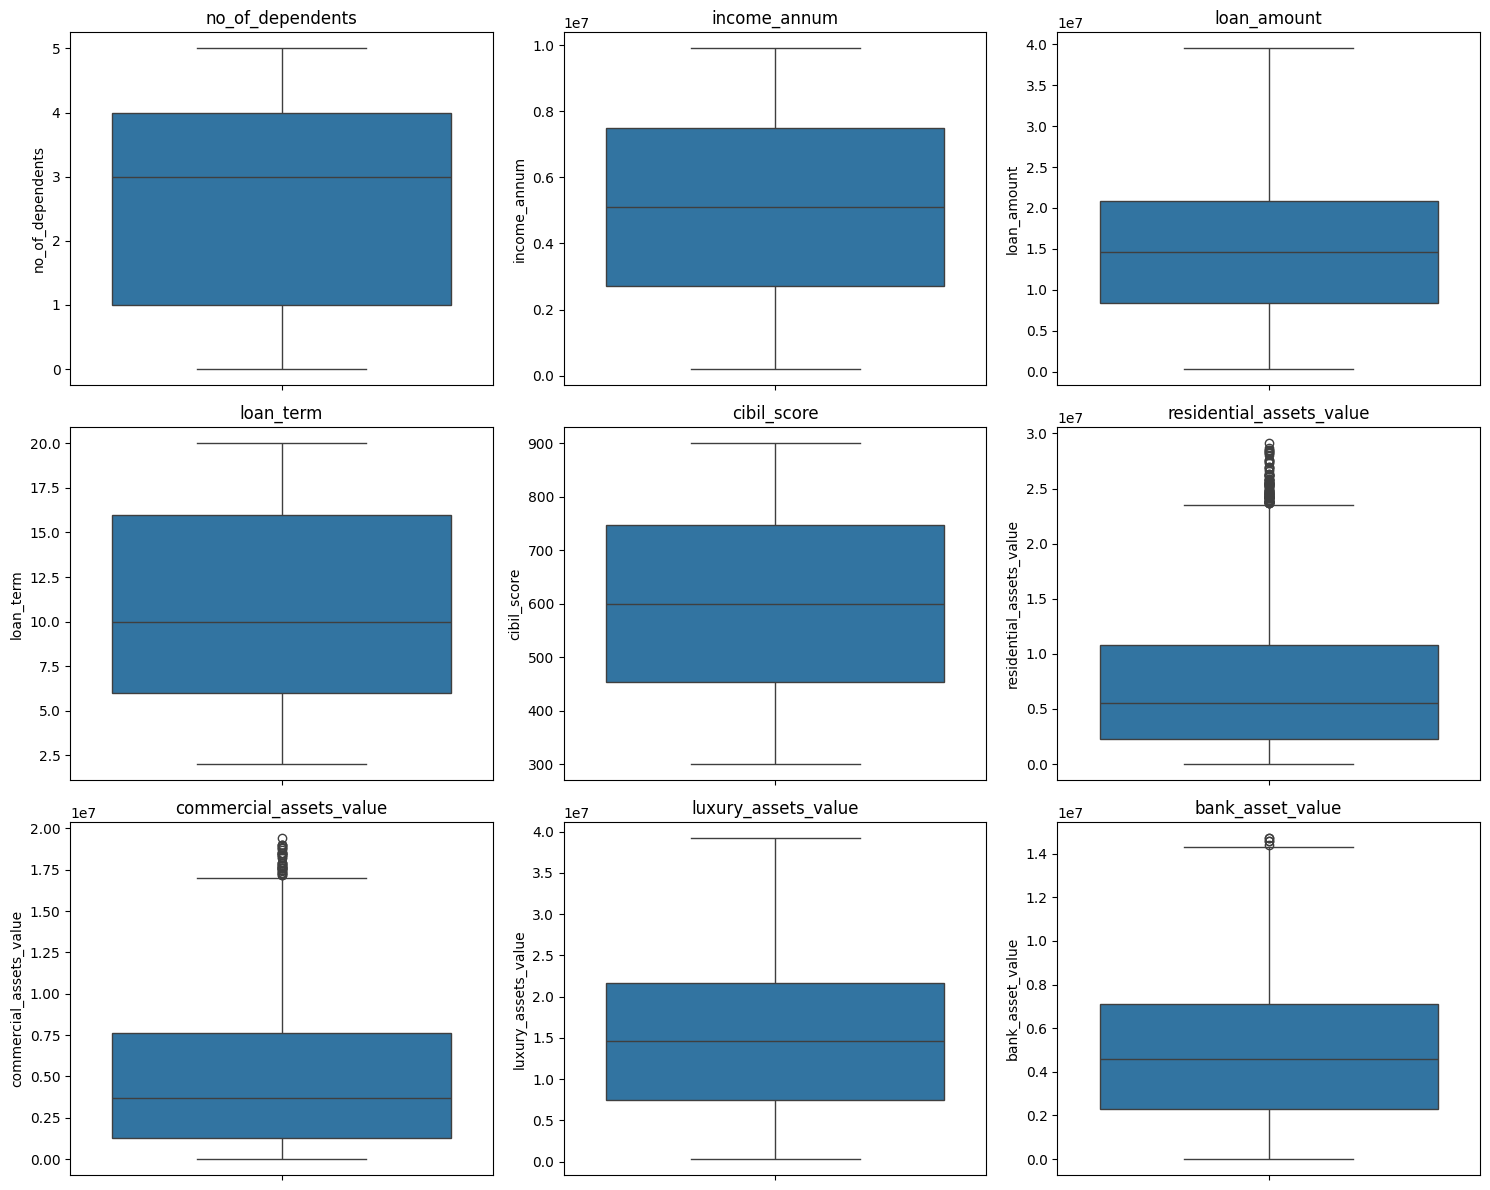

In [15]:
numerical_cols = df.select_dtypes(include=np.number).columns

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
۴.
    نمودار جعبه‌ای (Box Plot) از چه اجزایی تشکیل شده است؟ هر بخش آن را نام ببرید و توضیح دهید. همچنین توضیح دهید این نمودار با استفاده از چه روشی مقادیر پرت (Outliers) را شناسایی می‌کند و فرمول آن چیست؟

<div dir="rtl">

### نمودار جعبه‌ای (Box Plot)

نمودار جعبه‌ای یکی از ابزارهای مهم تحلیل اکتشافی داده‌ها است که برای نمایش توزیع داده‌ها، میزان پراکندگی و شناسایی مقادیر پرت استفاده می‌شود.

### اجزای نمودار جعبه‌ای

- **حداقل مقدار:** کوچک‌ترین مقدار داده که جزو مقادیر پرت محسوب نمی‌شود.
- **چارک اول:** مقداری که ۲۵ درصد داده‌ها کمتر یا مساوی آن هستند و لبه پایینی جعبه را تشکیل می‌دهد.
- **میانه:** مقداری که داده‌ها را به دو بخش مساوی تقسیم می‌کند و به‌صورت خطی در داخل جعبه نمایش داده می‌شود.
- **چارک سوم:** مقداری که ۷۵ درصد داده‌ها کمتر یا مساوی آن هستند و لبه بالایی جعبه را تشکیل می‌دهد.
- **جعبه:** ناحیه‌ای که ۵۰ درصد میانی داده‌ها را در بر می‌گیرد.
- **سبیل‌ها:** خطوطی که از دو طرف جعبه تا کوچک‌ترین و بزرگ‌ترین داده‌های غیرپرت امتداد پیدا می‌کنند.
- **مقادیر پرت:** نقاطی که فاصله زیادی از سایر داده‌ها دارند و خارج از محدوده سبیل‌ها قرار می‌گیرند.

### دامنه بین چارکی

دامنه بین چارکی، فاصله بین چارک سوم و چارک اول است که میزان پراکندگی ۵۰ درصد میانی داده‌ها را نشان می‌دهد:

$$IQR = Q_3 - Q_1$$

### روش شناسایی مقادیر پرت

ابتدا مقدار دامنه بین چارکی محاسبه می‌شود، سپس حدود مجاز داده‌ها به‌صورت زیر تعیین می‌شوند:

$$\text{Lower Bound} = Q_1 - 1.5 \times IQR$$

$$\text{Upper Bound} = Q_3 + 1.5 \times IQR$$

هر داده‌ای که کوچک‌تر از حد پایین یا بزرگ‌تر از حد بالا باشد، به عنوان مقدار پرت شناخته می‌شود.

</div>



<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
۵
    .
    با توجه به نمودارهای جعبه‌ای رسم‌شده، کدام ویژگی‌ها دارای مقادیر پرت (Outlier) هستند؟ برای هر کدام توضیح دهید که مقادیر پرت در کدام سمت توزیع (بالا یا پایین) قرار دارند.

<div dir="rtl">

بر اساس نمودارهای جعبه‌ای، سه ویژگی دارای مقادیر پرت هستند:

- **residential_assets_value:** در این ویژگی چندین مقدار پرت در بالای نمودار مشاهده می‌شود. این موضوع نشان می‌دهد که برخی نمونه‌ها دارای ارزش دارایی مسکونی به‌مراتب بیشتر از سایر داده‌ها هستند.

- **commercial_assets_value:** این ویژگی نیز دارای مقادیر پرت در سمت بالای توزیع است. وجود این نقاط نشان می‌دهد که ارزش دارایی تجاری برخی افراد به‌طور قابل توجهی از بقیه بیشتر است.

- **bank_asset_value:** در این ویژگی نیز چند مقدار پرت در قسمت بالایی نمودار دیده می‌شود که بیانگر دارایی بانکی بسیار بیشتر برخی نمونه‌ها نسبت به سایرین است.

برای سایر ویژگی‌ها شامل `no_of_dependents`، `income_annum`، `loan_amount`، `loan_term`، `cibil_score` و `luxury_assets_value` مقدار پرت قابل مشاهده‌ای وجود ندارد، زیرا هیچ نقطه‌ای خارج از محدوده سبیل‌های نمودار دیده نمی‌شود.

</div>

<div dir=rtl>
<h1>
<font face="B Nazanin" color=#0099cc>
عددی‌سازی ویژگی‌های دسته‌ای (Categorical Encoding)
<br>
</font>
<font face="B Nazanin" size=4>
مدل‌های یادگیری ماشین فقط با اعداد کار می‌کنند و نمی‌توانند مقادیر متنی را مستقیماً پردازش کنند. بنابراین باید ویژگی‌های دسته‌ای را به اعداد تبدیل کنیم تا مدل بتواند از آن‌ها یاد بگیرد.

<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-تعریف ویژگی دسته‌ای (Categorical Feature)
<div dir=rtl>
</font>
<font face="B Nazanin" size=4>
ویژگی دسته‌ای ویژگی‌ای است که مقادیر آن از یک مجموعه محدود و مشخص انتخاب می‌شوند و مقدار عددی پیوسته ندارند. این ویژگی‌ها به دو نوع تقسیم می‌شوند:
</p>
۱- Nominal — بین مقادیر هیچ ترتیب یا رتبه‌ای وجود ندارد.
</p>
۲- Ordinal — بین مقادیر یک ترتیب منطقی وجود دارد.
</p>

<div dir=rtl align=center>
<br>
<img src="https://www.scaler.com/topics/images/types-of-categorical-variables.webp" alt="Amirkabir University Logo" width="500">
<br>
<div> 
</p>

<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-روش های انکودینگ
<div dir=rtl>
</font>
<font face="B Nazanin" size=4>
برای تبدیل داده‌های طبقه‌بندی‌شده (Categorical) به داده‌های عددی، باید از روش‌های انکودینگ  استفاده کنیم. در این‌جا دو روش انکودینگ ساده معرفی می‌شود.

</p>

<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-روش One-Hot Encoding
<div dir=rtl>
</font>
<font face="B Nazanin" size=4>
در این روش، به ازای هر مقدار یک ویژگی با داده‌های طبقه‌بندی‌شده، یک ستون با داده‌های باینری ساخته می‌شود.
فرض کنید یک ویژگی مجموعه داده ما شامل مقادیر مختلف A، B، و C باشد و یکی از رکوردهای ما دارای مقدار B باشد. پس از انجام وان‌هات انکودینگ، ویژگی ما با سه ویژگی A, B، و C جایگزین می‌شود. داده‌ای که مقدار B داشت در ستون‌های A و C دارای مقدار `0` و در ستون B دارای مقدار `1` است.

</p>

<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-روش Ordinal Encoding
<div dir=rtl>
</font>
<font face="B Nazanin" size=4>
در این روش هر مقدار با یک عدد جایگزین می‌شود. در این روش باید اعداد جایگزین‌شده را انتخاب کنیم، این اعداد و فاصله‌شان با یکدیگر در عملکرد مدل تاثیر می‌گذارد و بنابراین باید به دقت انتخاب شوند.
به‌عنوان مثال اگر یک ویژگی با مقادیر Low، Medium و High داشته باشیم می‌توانیم آن را به یک ویژگی جدید با مقادیر `1`، `2` و `3` تبدیل کنیم.

</p>

<div dir=rtl>
<font face="B Nazanin" size=4>
اکنون شما ابتدا با دستور
'df.dtypes'
ویژگی های طبقه بندی شده(categorical)دیتاست را مشخص کنید. 
</p>
سپس با استفاده از دستور `()df["column_name"].unique` تمام مقادیر متفاوت ستون `column_name` را به ازای ستون های غیر عددی را مشاهده کنید.
</p>
و در نهایت  روش انکودینگ مناسب را برای هر مورد انتخاب کنید ویژگی‌های Categorical را به ویژگی‌های عددی تبدیل کنید.
</font>
</p>

In [16]:

print(df.dtypes)

no_of_dependents              int64
education                       str
self_employed                   str
income_annum                  int64
loan_amount                 float64
loan_term                     int64
cibil_score                   int64
residential_assets_value    float64
commercial_assets_value       int64
luxury_assets_value           int64
bank_asset_value              int64
loan_status                     str
dtype: object


In [17]:
# TODO: Select categorical columns from dataframe and display unique values of each
categorical_cols = df.select_dtypes(include="object").columns
for col in categorical_cols:
    print(col, "->", df[col].unique())

education -> <StringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str
self_employed -> <StringArray>
['No', 'Yes']
Length: 2, dtype: str
loan_status -> <StringArray>
['Approved', 'Rejected']
Length: 2, dtype: str


In [18]:
# TODO: Apply encoding to categorical features
df["education"] = df["education"].str.strip().map({"Not Graduate": 0, "Graduate": 1})

df["self_employed"] = df["self_employed"].str.strip().map({"No": 0, "Yes": 1})

df["loan_status"] = df["loan_status"].str.strip().map({"Rejected": 0, "Approved": 1})

# TODO: Print data types of dataframe features
print(df.dtypes)

no_of_dependents              int64
education                     int64
self_employed                 int64
income_annum                  int64
loan_amount                 float64
loan_term                     int64
cibil_score                   int64
residential_assets_value    float64
commercial_assets_value       int64
luxury_assets_value           int64
bank_asset_value              int64
loan_status                   int64
dtype: object


<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
۶.
علت انتخاب روش انکودینگ مورد استفاده برای هر مورد را توضیح دهید.

<div dir="rtl">

برای هر سه ستون از نگاشت مقادیر به اعداد ۰ و ۱ استفاده شد.

**۱. ستون education**

این ستون یک متغیر ترتیبی (Ordinal) است، زیرا بین مقادیر «Graduate» و «Not Graduate» یک ترتیب منطقی وجود دارد. بنابراین از Ordinal Encoding استفاده شد:

</div>

Not Graduate → 0  
Graduate → 1

<div dir="rtl">

این روش علاوه بر عددی‌سازی داده‌ها، ترتیب موجود بین مقادیر را نیز حفظ می‌کند.

**۲. ستون self_employed**

این ستون یک متغیر اسمی (Nominal) است و بین مقادیر «Yes» و «No» ترتیب خاصی وجود ندارد. اگرچه برای متغیرهای اسمی معمولاً از One-Hot Encoding استفاده می‌شود، اما چون این ویژگی تنها دو مقدار دارد، نگاشت مستقیم به ۰ و ۱ ساده‌تر و معادل آن است:

</div>

No → 0  
Yes → 1

<div dir="rtl">

**۳. ستون loan_status**

این ستون متغیر هدف (Target Variable) است و شامل دو کلاس «Approved» و «Rejected» می‌باشد. برای استفاده از آن در مدل‌  از Label Encoding استفاده شد:

</div>

Rejected → 0  
Approved → 1

<div dir="rtl">

این تبدیل، برچسب‌های متنی را به مقادیر عددی قابل پردازش توسط مدل تبدیل می‌کند.

</div>


<div dir=rtl>
<h1>
<font face="B Nazanin" color=#0099cc>
حذف داده های پرت
(Removing Outliers)
<br>
</font>
<font face="B Nazanin" size=4>
برخی رکوردها ممکن است مقادیری بسیار بزرگ یا کوچک داشته باشند و فاصله آن‌ها با میانگین یک ویژگی زیاد باشد. در تحلیل داده‌ها، داده‌های پرت (Outliers) می‌توانند تأثیر نامطلوبی بر نتایج مدل داشته باشند.
</p>
همان‌طور که در نمودار های جعبه‌ای (Box Plot) قسمت های قبل مشاهده کردید، برخی ستون‌ها دارای مقادیر پرت هستند. روشی که Box Plot برای شناسایی این مقادیر استفاده می‌کند، روش IQR است. IQR یک مقیاس آماری است که با محاسبه رنج بین چارک اول و سوم و داشتن یک ضریب، می‌تواند داده‌های پرت را شناسایی کند. 
</p>
توجه کنید که ویژگی‌های `residential_assets_value` و `commercial_assets_value` دارای توزیع چوله (Skewed) هستند و مقادیر بالای آن‌ها لزوماً پرت نیستند بلکه نشان‌دهنده مشتریان با دارایی بالا هستند. بنابراین برای این دو ستون از IQR استفاده نمی‌کنیم.
اکنون با توجه به نمودارهای جعبه‌ای رسم‌شده در بخش EDA، <<دو ستونی>> که دارای مقادیر پرت واقعی هستند را شناسایی کرده و با استفاده از تابع `remove_outliers_iqr()` داده‌های پرت آن‌ها را حذف کنید.
دقت کنید که باید تابع `()remove_outliers_iqr` را به گونه‌ای پیاده‌سازی کنید که تا زمانی که outlier در ستون وجود دارد، فرآیند حذف را تکرار کند و تنها زمانی متوقف شود که هیچ مقدار پرتی باقی نمانده باشد.

In [19]:
print("Shape before removing outliers:", df.shape)

def remove_outliers_iqr(df, col):
    while True:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        mask = (df[col] >= lower_bound) & (df[col] <= upper_bound)

        if mask.all():
            break

        df = df[mask].reset_index(drop=True)

    return df
df = remove_outliers_iqr(df, "bank_asset_value")

print(f"Shape after removing outliers: {df.shape}")


Shape before removing outliers: (4269, 12)
Shape after removing outliers: (4264, 12)


<div dir=rtl>
<font face="B Nazanin" size=4>
اکنون مجدداً نمودار جعبه‌ای ویژگی‌های عددی را رسم کنید و نتیجه را با نمودارهای رسم‌شده در بخش EDAبصری مقایسه کنید. 
</p>
دقت کنید که ویژگی‌های دسته‌ای encode شده تنها دارای مقادیر ۰ و ۱ هستند، بنابراین نمودار جعبه‌ای برای آن‌ها رسم نکنید.

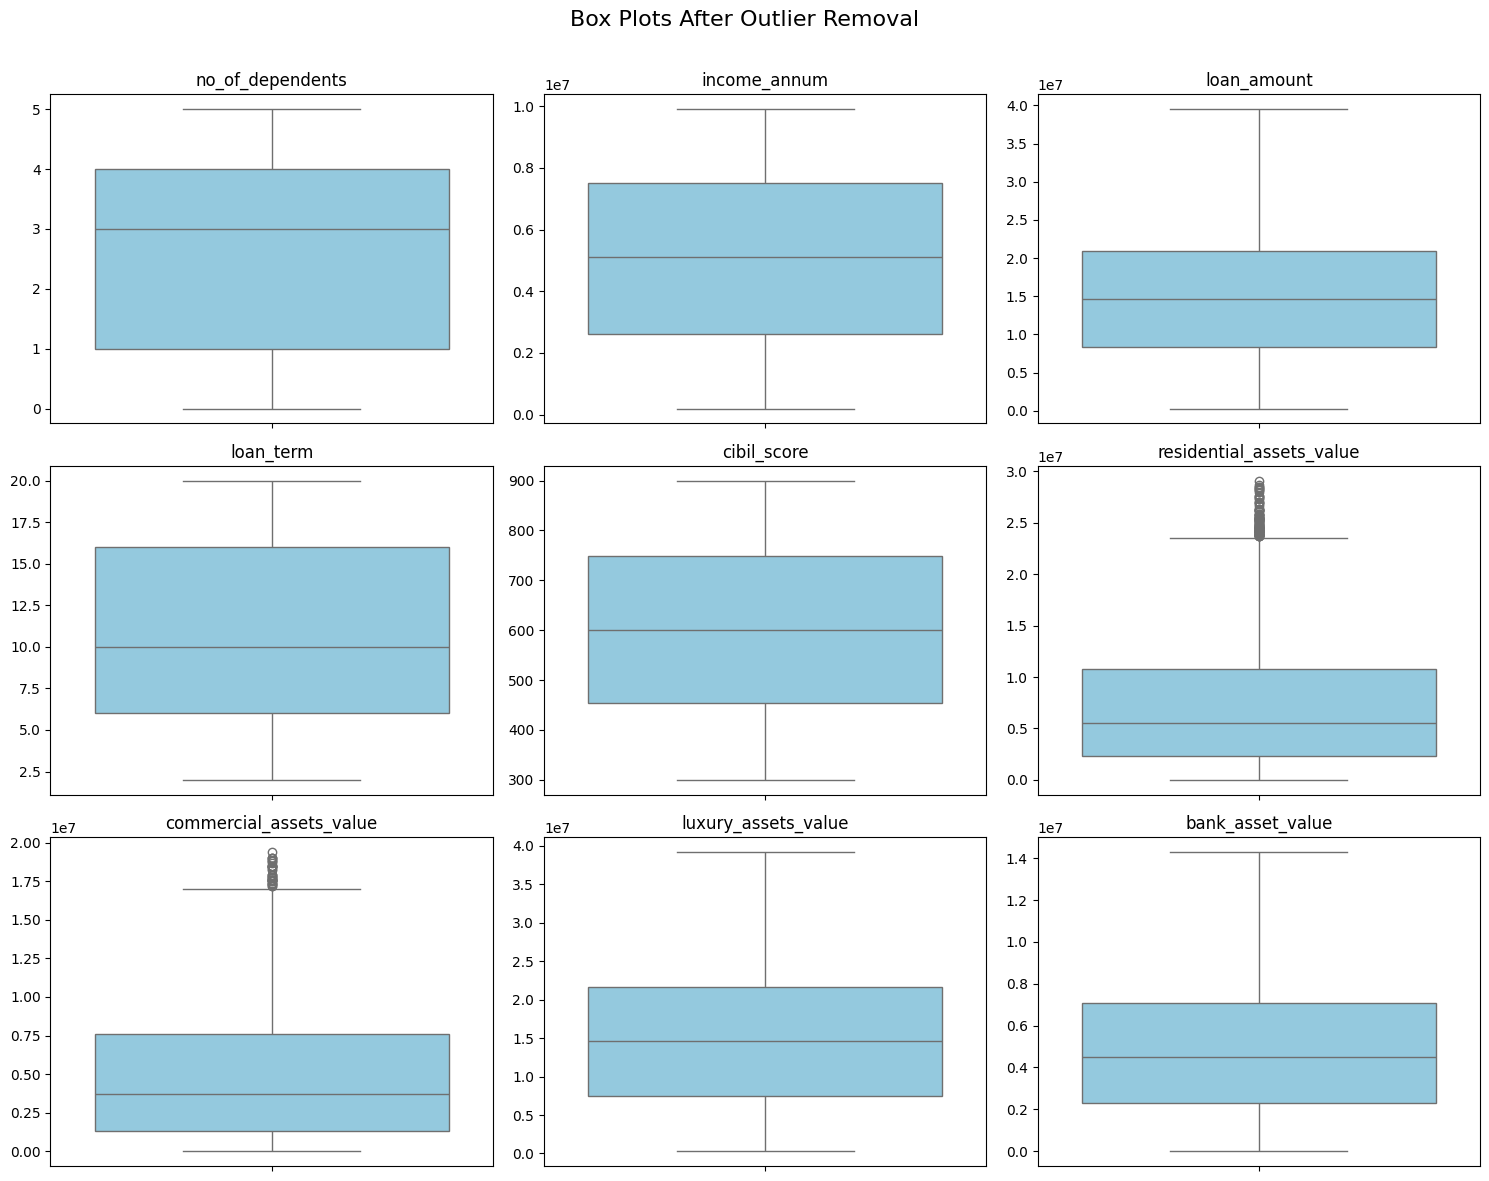

In [20]:

exclude_cols = ['education', 'self_employed', 'loan_status', 'loan_id']
numerical_cols = [col for col in df.select_dtypes(include='number').columns 
                  if col not in exclude_cols]

n = len(numerical_cols)
n_cols = 3
n_rows = (n + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col)
    axes[i].set_ylabel('')

for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Box Plots After Outlier Removal', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


<div dir=rtl>
<h1>
<font face="B Nazanin" color=#0099cc>
انتخاب ویژگی(Feature Selection)
<br>
</font>
<font face="B Nazanin" size=4>
انتخاب ویژگی یکی از مراحل مهم در پیش‌پردازش داده است که هدف آن حذف ویژگی‌های کم‌اهمیت, برای بهبود عملکرد مدل و کاهش پیچیدگی است. در این پروژه، از
دو روش آماری
ضریب پیرسون
 (Pearson Coefficient)
  و
  اطلاعات متقابل(Mutual Information)
   برای ارزیابی اهمیت ویژگی‌ها نسبت به متغیر هدف  استفاده می‌کنیم.


<div dir="rtl">
<font face="B Nazanin" size=4>
یک معیار آماری برای سنجش شدت و جهت رابطه‌ی خطی بین دو متغیر کمی است.
مقدارش بین 1- و 1+ قرار می‌گیرد:
<br><br>
1+ ← همبستگی خطی کامل مثبت <br>
1- ← همبستگی خطی کامل منفی <br>
0 ← نبود رابطه‌ی خطی
<br><br>
اکنون شما ضریب همبستگی پیرسون را بین ستون loan_status و سایر ویژگی‌های عددی محاسبه کنید و سپس به صورت نزولی آن را مرتب کنید.
</font>
</div>

In [21]:
# TODO: Calculate Pearson correlation coefficient between target column (loan_status) and all numerical features, then sort descending
pearson_corr = df.corr(numeric_only=True)['loan_status'].drop('loan_status')
ranked = pearson_corr.sort_values(ascending=False)
print("Pearson correlation with loan_status:")
print(ranked)


Pearson correlation with loan_status:
cibil_score                 0.770462
loan_amount                 0.014394
commercial_assets_value     0.009789
education                   0.004019
self_employed               0.001622
bank_asset_value           -0.005233
income_annum               -0.014312
luxury_assets_value        -0.014430
residential_assets_value   -0.015065
no_of_dependents           -0.017700
loan_term                  -0.113023
Name: loan_status, dtype: float64


<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
۷.
سه شرط برای استفاده از ضریب همبستگی پیرسون باید برقرار باشد، آن‌ها را نام ببرید و توضیح دهید که دلیل آن چیست؟

<div dir=rtl>

**۱. متغیرها کمی (عددی) باشند**

ضریب پیرسون برای اندازه‌گیری رابطه بین متغیرهای عددی طراحی شده است. اگر داده‌ها دسته‌ای یا اسمی باشند، مقدار ضریب پیرسون معنی‌دار نخواهد بود و باید از روش‌های دیگری استفاده شود.

**۲. بین دو متغیر رابطه خطی (Linear Relationship) وجود داشته باشد**

پیرسون میزان و جهت رابطه خطی بین دو متغیر را اندازه‌گیری می‌کند. اگر رابطه بین متغیرها غیرخطی باشد، ممکن است ضریب پیرسون مقدار نزدیک به صفر نشان دهد، حتی زمانی که بین متغیرها وابستگی قوی وجود دارد.

**۳. داده‌ها فاقد مقادیر پرت شدید (Extreme Outliers) باشند**

ضریب پیرسون به مقادیر پرت حساس است. وجود چند مقدار بسیار بزرگ یا بسیار کوچک می‌تواند مقدار ضریب همبستگی را به‌طور قابل توجهی تغییر دهد و باعث شود نتیجه به‌درستی بیانگر رابطه واقعی بین متغیرها نباش

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
۸.  
.فرمول استاندارد ضریب همبستگی پیرسون را برای دو متغیر بنویسید و شهود پشت این فرمول را با یک مثال توضیح دهید 

ضریب همبستگی پیرسون برای دو متغیر $X$ و $Y$ به صورت زیر تعریف می‌شود:

$$
r = \frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}
{\sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2}\sqrt{\sum_{i=1}^{n}(y_i-\bar{y})^2}}
$$

که در آن:

- $x_i$ و $y_i$ مقادیر مشاهده‌شده هستند.
- $\bar{x}$ و $\bar{y}$ میانگین متغیرهای $X$ و $Y$ هستند.
- $n$ تعداد مشاهدات است.


ضریب همبستگی پیرسون بررسی می‌کند که آیا دو متغیر تمایل دارند در یک جهت تغییر کنند یا در جهت مخالف.

**رابطه مستقیم (مثبت):**
اگر دو متغیر رابطه مستقیم داشته باشند، با افزایش یکی، دیگری نیز افزایش می‌یابد و با کاهش یکی، دیگری نیز کاهش پیدا می‌کند. در این حالت انحراف هر دو متغیر از میانگین معمولاً هم‌علامت است و ضریب پیرسون مثبت می‌شود.

برای مثال، بین درآمد سالانه و مبلغ وام معمولاً رابطه مستقیم وجود دارد؛ افرادی که درآمد بیشتری دارند اغلب وام‌های بزرگ‌تری دریافت می‌کنند.

**رابطه معکوس (منفی):**
اگر دو متغیر رابطه معکوس داشته باشند، افزایش یکی با کاهش دیگری همراه است. در این حالت انحراف دو متغیر از میانگین معمولاً علامت‌های مخالف دارند و ضریب پیرسون منفی می‌شود.

برای مثال، با افزایش نرخ بهره وام ممکن است تعداد درخواست‌های وام کاهش یابد.

**جمع‌بندی:**
ایده اصلی فرمول این است که بررسی کند تغییرات دو متغیر تا چه اندازه با یکدیگر همسو هستند:

- هرچه همسویی بیشتر باشد، مقدار ضریب به $+1$ نزدیک‌تر می‌شود.
- هرچه تغییرات در جهت مخالف باشند، مقدار ضریب به $-1$ نزدیک‌تر می‌شود.
- اگر الگوی خطی مشخصی وجود نداشته باشد، مقدار ضریب به $0$ نزدیک می‌شود.



<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-اطلاعات متقابل(Mutual Information)
<div dir=rtl>
</font>
<font face="B Nazanin" size=4>
یک معیار است که میزان وابستگی بین دو متغیر را اندازه‌گیری می‌کند. برخلاف ضریب همبستگی پیرسون که فقط روابط خطی را تشخیص می‌دهد، MI می‌تواند روابط غیرخطی را هم شناسایی کند و مقدارش همیشه غیرمنفی است و هرچه بالاتر باشد، وابستگی بیشتر است.
</p>
توجه کنید که تابع `mutual_info_classif` به صورت پیش‌فرض همه ویژگی‌ها را پیوسته (Continuous) فرض می‌کند. برای ویژگی‌هایی که مقادیر گسسته دارند این فرض اشتباه است و مقدار MI را به صورت نادرست محاسبه می‌کند. ابتدا با استفاده از `df.nunique()` ویژگی‌های گسسته را شناسایی کنید و سپس آن‌ها را با پارامتر `discrete_features` مشخص کنید.
اکنون معیار اطلاعات متقابل را با در نظر گرفتن نوع هر ویژگی نسبت به ستون هدف محاسبه کنید و به صورت مرتب‌شده نمایش دهید.

</p>

In [22]:

X = df.drop(columns=['loan_status'])
y = df['loan_status']
discrete_mask = X.nunique() <= 10

mi_scores = mutual_info_classif(X, y, discrete_features=discrete_mask)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
print("Mutual Information with loan_status:")
print(mi_series)

Mutual Information with loan_status:
cibil_score                 0.505427
loan_term                   0.019454
luxury_assets_value         0.005839
no_of_dependents            0.000271
education                   0.000008
self_employed               0.000001
loan_amount                 0.000000
income_annum                0.000000
residential_assets_value    0.000000
commercial_assets_value     0.000000
bank_asset_value            0.000000
dtype: float64


<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
۹.  
فرمول اطلاعات متقابل (Mutual Information) را برای دو متغیر بنویسید و شهود پشت این فرمول را با یک مثال توضیح دهید.
همچنین بگویید 
با مقایسه نتایج اطلاعات متقابل (MI) و ضریب همبستگی پیرسون، کدام ویژگی‌ها به عنوان مهم‌ترین پیش‌بینی‌کننده‌های وضعیت وام شناسایی می‌شوند؟

<div dir="rtl">

**فرمول اطلاعات متقابل (Mutual Information)**

اطلاعات متقابل بین دو متغیر $X$ و $Y$ به صورت زیر تعریف می‌شود:

$$MI(X,Y) = \sum_{x}\sum_{y} p(x,y)\,\log\left(\frac{p(x,y)}{p(x)\,p(y)}\right)$$

که در آن $p(x,y)$ احتمال مشترک وقوع $X=x$ و $Y=y$ و $p(x)$ و $p(y)$ به‌ترتیب احتمال وقوع $X$ و $Y$ هستند.

**شهود پشت فرمول**

اطلاعات متقابل اندازه‌گیری می‌کند که دانستن مقدار یک متغیر تا چه اندازه عدم قطعیت درباره متغیر دیگر را کاهش می‌دهد. اگر دو متغیر کاملاً مستقل باشند، دانستن مقدار یکی هیچ اطلاعاتی درباره دیگری ارائه نمی‌دهد و مقدار MI برابر صفر خواهد بود. هرچه وابستگی بین دو متغیر بیشتر باشد، مقدار MI نیز بزرگ‌تر خواهد شد.

به عنوان مثال، در مسئله اعطای وام، اگر امتیاز اعتباری (`cibil_score`) تأثیر زیادی بر وضعیت تأیید یا رد وام داشته باشد، با دانستن امتیاز اعتباری می‌توان با دقت بیشتری وضعیت وام را پیش‌بینی کرد. در این حالت اطلاعات متقابل بین این دو متغیر زیاد خواهد بود. برخلاف ضریب همبستگی پیرسون، اطلاعات متقابل تنها به روابط خطی محدود نیست و می‌تواند وابستگی‌های غیرخطی را نیز شناسایی کند.

**مقایسه نتایج MI و ضریب همبستگی پیرسون**

بر اساس نتایج محاسبه‌شده، ویژگی `cibil_score` با اختلاف زیاد بیشترین مقدار اطلاعات متقابل (حدود $0.505$) را دارد و مهم‌ترین پیش‌بینی‌کننده وضعیت وام محسوب می‌شود. پس از آن، ویژگی `loan_term` دارای بیشترین مقدار MI در میان سایر ویژگی‌ها است، هرچند تأثیر آن بسیار کمتر از `cibil_score` می‌باشد.

همچنین ویژگی‌های `residential_assets_value` و `income_annum` دارای مقادیر مثبت اما کوچک هستند و اطلاعات محدودی درباره وضعیت وام ارائه می‌کنند. سایر ویژگی‌ها مقدار MI بسیار ناچیزی دارند و نقش قابل توجهی در پیش‌بینی وضعیت وام ایفا نمی‌کنند.

با مقایسه نتایج اطلاعات متقابل و ضریب همبستگی پیرسون مشاهده می‌شود که `cibil_score` در هر دو معیار به عنوان مهم‌ترین ویژگی شناخته می‌شود. بنابراین می‌توان نتیجه گرفت که `cibil_score` اصلی‌ترین عامل مؤثر در پیش‌بینی وضعیت تأیید یا رد وام است و پس از آن `loan_term` و تا حدی `income_annum` و `residential_assets_value` دارای اهمیت هستند.

</div>


<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-انتخاب ویژگی
<div dir=rtl>
</font>
<font face="B Nazanin" size=4>
در این مرحله، برای انتخاب ویژگی‌های نهایی از ترکیب ضریب همبستگی پیرسون و اطلاعات متقابل استفاده می‌کنیم. هدف این روش، شناسایی ویژگی‌هایی است که بیشترین ارتباط را با متغیر هدف (loan_status) دارند، چه به‌صورت خطی و چه غیرخطی.
</p>
برای معیار پیرسون، از میانه‌ی مقادیر همبستگی به عنوان آستانه استفاده کنید تا ویژگی‌هایی که همبستگی خطی قابل‌توجهی با ستون هدف دارند انتخاب شوند.
</p>
برای معیار اطلاعات متقابل، آستانه‌ی عددی ثابت 0.0005 در نظر گرفته شده است و ویژگی‌هایی که مقدار MI آن‌ها از این آستانه بیشتر است انتخاب می‌شوند.
</p>
در نهایت، تمام ویژگی‌هایی که حداقل یکی از دو شرط بالا را برآورده می‌کنند به‌عنوان ویژگی‌های منتخب در مدل نگه دارید.

</p>

In [23]:

pearson_abs = pearson_corr.abs()
pearson_threshold = pearson_abs.median()
pearson_selected = pearson_abs[pearson_abs >= pearson_threshold].index.tolist()

mi_threshold = 0.00005
mi_selected = mi_series[mi_series >= mi_threshold].index.tolist()

selected_features = list(set(pearson_selected) | set(mi_selected))

print("Selected features:", selected_features)
print("Number of selected features:", len(selected_features))

df = df[selected_features + ['loan_status']]
print("Shape after feature selection:", df.shape)


Selected features: ['residential_assets_value', 'luxury_assets_value', 'loan_term', 'cibil_score', 'no_of_dependents', 'loan_amount']
Number of selected features: 6
Shape after feature selection: (4264, 7)


<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
۱۰.  
آیا ویژگی‌های انتخاب‌شده بر اساس معیارهای ضریب همبستگی پیرسون و اطلاعات متقابل، با نتایج حاصل از هیت مپ همبستگی که در قسمت های قبل به دست آورده بودید, درباره ارتباط میان ویژگی‌ها و هدف هم‌خوانی دارند؟
توضیح دهید و در صورت وجود تفاوت، دلیل احتمالی آن را بیان کنید.

<div dir="rtl" style=>

بله، نتایج به‌طور کلی با هیت‌مپ همبستگی هم‌خوانی دارند. ویژگی cibil_score در هر سه روش (ضریب همبستگی پیرسون، اطلاعات متقابل و هیت‌مپ) به‌عنوان مهم‌ترین ویژگی شناسایی شد و loan_term نیز به دلیل همبستگی کم با سایر ویژگی‌ها، اطلاعات مستقلی در اختیار مدل قرار می‌دهد.

با این حال، در مورد برخی ویژگی‌های مالی مانند income_annum، loan_amount و residential_assets_value تفاوتی مشاهده می‌شود. این ویژگی‌ها در معیارهای پیرسون و اطلاعات متقابل دارای اهمیت هستند، اما هیت‌مپ نشان می‌دهد که بین آن‌ها همبستگی بالایی وجود دارد و بخشی از اطلاعات آن‌ها تکراری است.

دلیل این تفاوت آن است که معیارهای پیرسون و اطلاعات متقابل، هر ویژگی را به‌صورت جداگانه نسبت به متغیر هدف ارزیابی می‌کنند، در حالی که هیت‌مپ علاوه بر ارتباط با هدف، روابط میان خود ویژگی‌ها را نیز نشان می‌دهد. بنابراین هیت‌مپ می‌تواند وجود هم‌خطی و افزونگی اطلاعات بین ویژگی‌ها را آشکار کند.

</div>


<div dir=rtl>
<h1>
<font face="B Nazanin" color=#0099cc>
تقسیم داده به مجموعه آموزش و آزمون (Train/Test Split)
<br>
</font>
<font face="B Nazanin" size=4>
برای اینکه عملکرد واقعی مدل را بسنجیم، باید داده‌هایی به آن بدهیم که در مرحله آموزش ندیده است. به همین دلیل دیتاست را به دو بخش تقسیم می‌کنیم: بخش آموزش (Train) که برای یادگیری پارامترهای مدل استفاده می‌شود، و بخش آزمون (Test) که صرفاً برای ارزیابی عملکرد مدل به کار می‌رود و هیچ نقشی در فرآیند آموزش ندارد.

In [24]:

X = df.drop(columns=["loan_status"])
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (3411, 6)
X_test shape: (853, 6)
y_train shape: (3411,)
y_test shape: (853,)


<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
۱۱.
    تحقیق کنید نشت داده (Data Leakage) چیست و چه عواملی می‌توانند منجر به آن شوند؟ توضیح دهید.

<div dir="rtl" >

نشت داده (Data Leakage) به حالتی گفته می‌شود که در آن اطلاعاتی وارد فرآیند آموزش مدل می‌شود که در زمان پیش‌بینی واقعی نباید در دسترس باشد. این موضوع باعث می‌شود مدل به‌جای یادگیری الگوهای واقعی، از اطلاعات نادرست یا آینده‌نگر استفاده کند و در نتیجه هرچند روی داده‌های آزمایشی عملکرد خیلی خوبی نشان می‌دهد، اما در عمل و روی داده‌های جدید دقت آن به‌طور قابل توجهی کاهش پیدا می‌کند.

یکی از مهم‌ترین دلایل نشت داده این است که مراحل پیش‌پردازش مثل نرمال‌سازی، استانداردسازی یا پر کردن داده‌های گمشده قبل از جدا کردن داده‌های Train و Test انجام شوند، چون در این حالت اطلاعات مجموعه Test به‌طور غیرمستقیم وارد آموزش می‌شود. همچنین استفاده از ویژگی‌هایی که بعد از وقوع نتیجه ایجاد می‌شوند یا به نوعی پاسخ را لو می‌دهند، می‌تواند باعث نشت هدف شود. در مسائل مربوط به داده‌های زمانی نیز اگر داده‌ها به‌صورت تصادفی تقسیم شوند و ترتیب زمانی رعایت نشود، اطلاعات آینده به مدل داده می‌شود که این هم نوعی نشت محسوب می‌شود. علاوه بر این، انجام انتخاب ویژگی روی کل داده قبل از تقسیم‌بندی یا وجود داده‌های تکراری در هر دو مجموعه Train و Test نیز از عوامل دیگر این مشکل هستند.

به طور کلی برای جلوگیری از نشت داده باید ابتدا داده‌ها به درستی به Train و Test تقسیم شوند و سپس تمام مراحل پردازش فقط روی داده‌های Train انجام گیرد تا مدل فقط از اطلاعات واقعی و قابل دسترس در زمان پیش‌بینی یاد بگیرد.

</div>


<div dir=rtl>
<h1>
<font face="B Nazanin" color=#0099cc>
متعادل‌سازی کلاس‌ها (Class Imbalance Handling)
<br>
</font>
<font face="B Nazanin" size=4>
در مسائل دسته‌بندی ، گاهی تعداد نمونه‌های یک کلاس بسیار بیشتر از کلاس دیگر است. این عدم تعادل باعث می‌شود مدل به سمت کلاس اکثریت bias پیدا کند و الگوهای کلاس اقلیت را یاد نگیرد. توجه کنید که عملیات متعادل‌سازی کلاس‌ها فقط روی داده‌های آموزش (Train) انجام می‌شود و داده‌های آزمون (Test) باید کاملاً دست‌نخورده باقی بمانند.
</p>
اکنون شما ابتدا ابتدا با استفاده از متد `value_counts()` توزیع کلاس‌های ستون هدف را در داده آموزش بررسی کنید.

In [25]:
# TODO: Check target column class balance in training data using value_counts and print results
print("Class distribution in training data:")
print(y_train.value_counts())

print("\nClass distribution (proportion):")
print(y_train.value_counts(normalize=True))


Class distribution in training data:
loan_status
1    2134
0    1277
Name: count, dtype: int64

Class distribution (proportion):
loan_status
1    0.625623
0    0.374377
Name: proportion, dtype: float64


<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
۱۲.
    در چه شرایطی استفاده از resampling ضروری است و چه زمانی نیازی به آن نیست؟

<div dir="rtl">

<p>وقتی عدم‌تعادل کلاس‌ها شدید باشد (مثلاً 1:100 یا بیشتر)، resampling ضروری می‌شود چون مدل معمولاً به سمت کلاس اکثریت می‌رود و کلاس اقلیت را یاد نمی‌گیرد؛ مثل مسائل تقلب، بیماری‌های نادر یا تشخیص نفوذ. همچنین وقتی تعداد نمونه‌های کلاس اقلیت خیلی کم باشد یا هزینه خطای آن بالا باشد (مثل سرطان) و معیارهایی مثل recall مهم باشند، resampling مفید است. اگر هم روش‌های ساده‌تر جواب ندهداز resampling استفاده می‌شود.</p>

<p>اما وقتی عدم‌تعادل ملایم باشد (مثل 62.6٪ در برابر 37.4٪)، یا هر دو کلاس داده کافی داشته باشند، معمولاً نیازی به آن نیست. همچنین اگر توزیع داده باید واقعی بماند یا بتوان مشکل را با class_weight حل کرد، بهتر است resampling انجام نشود چون می‌تواند توزیع را مصنوعی کرده و حتی دقت احتمالات را خراب کند.</p>

<p>نکته مهم اینکه resampling فقط باید روی داده Train انجام شود، نه Test، چون باعث نشت داده می‌شود. oversampling ممکن است overfitting ایجاد کند و undersampling هم اطلاعات را کم می‌کند، پس بهتر است اول روش‌های ساده‌تر بررسی شوند.</p>

</div>


<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-سه روش متعادل سازی کلاس ها
<div dir=rtl>
</font>
<font face="B Nazanin" size=4>
۱. Random OverSampling — نمونه‌های کلاس اقلیت به صورت تصادفی تکرار می‌شوند.
</p>
۲. Random UnderSampling — نمونه‌هایی از کلاس اکثریت به صورت تصادفی حذف می‌شوند.
</p>
۳. SMOTE — به جای تکرار نمونه‌های موجود، نمونه‌های مصنوعی جدید برای کلاس اقلیت تولید می‌کند.
</p>
اکنون شما
 روش مناسب را انتخاب کرده و سپس آن را روی داده‌های آموزش اعمال کنید.

In [26]:

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Class distribution BEFORE SMOTE:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

print("\nClass distribution AFTER SMOTE:")
print(pd.Series(y_train_resampled).value_counts())
print(pd.Series(y_train_resampled).value_counts(normalize=True) * 100)

Class distribution BEFORE SMOTE:
loan_status
1    2134
0    1277
Name: count, dtype: int64
loan_status
1    62.562298
0    37.437702
Name: proportion, dtype: float64

Class distribution AFTER SMOTE:
loan_status
1    2134
0    2134
Name: count, dtype: int64
loan_status
1    50.0
0    50.0
Name: proportion, dtype: float64


<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
۱۳.
    دلیل استفاده از روش مدنظرتان را توضیح دهید.همچنین به طور کلی مزایا و معایب این سه روش متعادل سازی کلاس ها رو بیان کنید.
    همچنین بیان کنید چرا باید روش موردنظر را فقط روی داده های آموزش اعمال کرد.

<div dir="rtl">


در این مسئله از SMOTE استفاده شده است، زیرا این روش به‌جای تکرار نمونه‌های موجود (مانند Random OverSampling) یا حذف بخشی از داده‌ها (مانند Random UnderSampling)، نمونه‌های مصنوعی جدیدی برای کلاس اقلیت تولید می‌کند. در نتیجه، مدل با نمونه‌های متنوع‌تری از کلاس اقلیت مواجه می‌شود و بدون از دست رفتن اطلاعات کلاس اکثریت، تعادل بهتری در داده‌ها ایجاد می‌شود. همچنین از آنجا که ویژگی‌های این مسئله عمدتاً عددی و پیوسته هستند، SMOTE که بر پایه فاصله و درون‌یابی بین نمونه‌ها عمل می‌کند، برای این داده‌ها انتخاب مناسبی است.



در Random OverSampling نمونه‌های کلاس اقلیت به‌صورت تصادفی تکرار می‌شوند که روش ساده‌ای است اما می‌تواند باعث overfitting شود. در Random UnderSampling بخشی از داده‌های کلاس اکثریت حذف می‌شود که باعث سریع‌تر شدن آموزش می‌شود، اما ممکن است اطلاعات مهم از دست برود. در مقابل، SMOTE با ساخت نمونه‌های مصنوعی بین داده‌های موجود، تعادل بهتری ایجاد می‌کند، اما در داده‌های نویزی یا پیچیده ممکن است نمونه‌های غیرواقعی تولید کند.



دلیل اینکه این روش‌ها فقط باید روی داده‌های آموزش (Train) اعمال شوند این است که داده‌های آزمون باید کاملاً دست‌نخورده باقی بمانند تا ارزیابی مدل واقعی و منصفانه باشد. اگر SMOTE قبل از split انجام شود، ممکن است نمونه‌های مصنوعی وارد Train و Test شوند یا حتی ارتباطی بین آن‌ها ایجاد شود (مثلاً یک نمونه مصنوعی در Train و نمونه‌های والد آن در Test قرار گیرند) که این موضوع باعث نشت داده و نتیجه‌گیری غیرواقعی از عملکرد مدل می‌شود.


</div>


<div dir=rtl>
<h1>
<font face="B Nazanin" color=#0099cc>
استاندارد سازی و نرمال سازی داده ها
<br>
</font>
<font face="B Nazanin" size=4>
ویژگی‌های متفاوت، مقادیر و واحدهای متفاوتی دارند. با نرمال‌سازی می‌توانیم مقادیر یک ویژگی را به یک رنج خاص (معمولاً $[0, 1]$) ببریم. با استانداردسازی مقادیر را به گونه‌ای تبدیل می‌کنیم که میانگین صفر و انحراف معیار یک داشته باشند. هر دو روش تضمین می‌کنند که واحدهای ویژگی‌های متفاوت تأثیر یکسانی در عملکرد مدل داشته باشند.
 روش‌ها و فرمول‌های مختلفی برای نرمال‌سازی و استانداردسازی وجود دارد که در اینجا یکی از هر کدام را توضیح می‌دهیم.
</p>
توجه:دقت کنید که 
ابتدا  برازش‌دهنده (scaler)  را فقط روی داده‌های آموزش fit می‌کنیم تا مقیاس‌دهی بر اساس همان داده‌ها یاد گرفته شود. سپس همان برازش‌دهنده() را روی داده‌های تست نیز اعمال می‌کنیم، زیرا در دنیای واقعی داده‌های جدید باید با همان مقیاس داده‌های آموزش نرمال‌سازی شوند تا مدل بتواند آن‌ها را درست پردازش کند.

<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-
نرمال‌سازی Min-Max
</font>
<font face="B Nazanin" size=4>

- اگر یک داده با مقدار $X$ داشته باشیم، مقدار نرمال‌سازی‌شده را از فرمول زیر به دست می‌آوریم:
<div dir=ltr>
    
$$X_{\text{normalized}} = \frac{X - X_{\text{min}}}{X_{\text{max}} - X_{\text{min}}}$$
<div dir=rtl>
</p>
در نرمال‌سازی هدف ما بردن داده‌ها به یک بازه مشخص است. این روش به داده‌های پرت حساس است و برای الگوریتم‌هایی مناسب است که بر اساس فاصله کار می‌کنند.
</p>
برای محاسبه این مقدار می‌توانید از کلاس `()MinMaxScaler` در کتاب‌خانه sklearn استفاده کنید.
</p>

<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-
استانداردسازی Z-Score
</font>
<font face="B Nazanin" size=4>   
    
- اگر یک داده با مقدار $X$، و $\mu$ میانگین کل داده‌های آن ویژگی، و $\sigma$ انحراف معیار داده‌های آن ویژگی باشد، آن‌گاه مقدار استانداردشده را از فرمول زیر به دست می‌آوریم:
<div dir=ltr>

$$X_{\text{standardized}} = \frac{X - \mu}{\sigma}$$
<div dir=rtl>
</p>
در استانداردسازی، میانگین داده‌ها را به صفر می‌بریم به‌طوری که انحراف معیار برابر با یک شود. استانداردسازی بر خلاف نرمال‌سازی بازه مشخصی ندارد و بنابراین به داده‌های پرت حساسیت کمی دارد.
</p>
برای محاسبه این مقدار می‌توانید از کلاس `()StandardScaler` در کتاب‌خانه sklearn استفاده کنید.

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
۱۴.
تحقیق کنید که برای ویژگی‌های موجود در این مجموعه داده و هدف اصلی این پروژه  کدام روش مناسب است و علت آن را توضیح دهید. سپس در سلول زیر داده‌ها را استاندارد و یا نرمال کنید.

<div dir="rtl">

**استانداردسازی Z-Score مناسب‌تر است**

**1-وجود داده‌های پرت و توزیع چوله در این دیتاست:**

ویژگی‌های مالی این مجموعه مثل `commercial_assets_value` و `residential_assets_value` ذاتاً چوله به راست (right-skewed) هستند؛ یعنی تعداد کمی متقاضی با دارایی بسیار بالا وجود دارند که به‌عنوان داده‌ی پرت عمل می‌کنند.

Min-Max کل بازه را به $[0, 1]$ فشرده می‌کند و به همین دلیل به یک مقدار بیشینه شدیداً حساس است. اگر فقط یک متقاضی درآمد بسیار بالایی داشته باشد، بقیه‌ی داده‌ها در گوشه‌ی کوچکی نزدیک صفر متراکم می‌شوند و تفاوت‌های واقعی بین آن‌ها از بین می‌رود.

Z-Score بر اساس میانگین و انحراف معیار کار می‌کند و به این مقادیر حدی به‌مراتب کم‌حساس‌تر است؛ ساختار و پراکندگی داده حفظ می‌شود.

**2- تفاوت شدید مقیاس ویژگی‌ها:**

مقیاس‌ها کاملاً ناهمگن‌اند: `cibil_score` در بازه ۳۰۰ تا ۹۰۰، `loan_term` اعداد کوچک، اما `income_annum` و ارزش دارایی‌ها در مقیاس میلیونی. Z-Score همه را به یک واحد مشترک (میانگین صفر، انحراف معیار یک) می‌برد، بدون اینکه به مرزهای دقیق کمینه/بیشینه وابسته باشد.

  Min-Maxزمانی بهتر بود که داده‌های پرت نداشتیم و حتماً به مقادیر در بازه‌ی محدود $[0, 1]$ نیاز داشتیم. در این دیتاست هیچ‌کدام برقرار نیست .

</div>



In [27]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (4268, 6)
X_test_scaled shape: (853, 6)


<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
۱۵.
    آیا نرمال‌سازی و استانداردسازی باید روی ستون هدف \هم اعمال شود؟ چرا؟

<div dir="rtl">

خیر، نباید روی ستون هدف (loan_status) اعمال شود.


ستون هدف در این پروژه یک متغیر رده‌ای/دسته‌ای است (۰ و ۱ = رد یا تأیید وام). این مقادیر صرفاً برچسب هستند، نه کمیت عددی قابل مقیاس‌بندی؛ بنابراین استانداردسازی آن‌ها بی‌معنی است و فقط برچسب‌ها را به اعداد اعشاری نامفهوم تبدیل می‌کند.


از طرف دیگر، هدف از scaling این است که ویژگی‌ها در یک مقیاس قرار بگیرند تا الگوریتم به ویژگی‌های بزرگ‌مقیاس وزن بیشتری ندهد، در حالی که ستون هدف اصلاً به این شکل وارد محاسبات فاصله یا گرادیان نمی‌شود و مدل آن را تنها به‌عنوان خروجی پیش‌بینی می‌کند.


علاوه بر این، اگر هدف را scale کنیم، معیارهایی مثل Accuracy، Precision، Recall و Confusion Matrix دیگر قابل محاسبه نخواهند بود، چون به برچسب‌های گسسته نیاز دارند، و خروجی مدل هم دیگر مستقیماً قابل تفسیر به «تأیید/رد» نخواهد بود.

</div>


<div dir="rtl">
    
## <font face="B Nazanin" color="#0099cc">اعتبارسنجی متقابل و بهینه‌سازی فراپارامترها (Cross Validation & Hyperparameter Tuning)</font>

## <font face="B Nazanin" color="#0099cc">اعتبارسنجی متقابل (Cross-Validation)</font>

<font face="B Nazanin" size="4">
</p>
روشی برای ارزیابی عملکرد یک مدل است، بدون اینکه همه داده‌ها را برای آموزش استفاده کند تا دچار بیش‌برازش (Overfitting) نشود.
</p>
به این صورت که داده را به چند تکه (مثلاً ۵ تکه) تقسیم می‌کند. هر بار یکی از تکه‌ها را برای تست و بقیه را برای آموزش استفاده می‌کند. این کار را تکرار می‌کند تا همه تکه‌ها نقش تست را بازی کنند.
</p>
هدف این روش این است که بفهمیم مدل روی داده‌های دیده‌نشده چقدر خوب عمل می‌کند.

</font>


### <font face="B Nazanin" color="#0099cc">پارامترهای مدل:</font>

<font face="B Nazanin" size="4">
</p>
مقادیری هستند که مدل طی آموزش یاد می‌گیرد (مثل وزن‌ها در رگرسیون خطی)

</font>

### <font face="B Nazanin" color="#0099cc">فراپارامترها:</font>

<font face="B Nazanin" size="4">
</p>
مقادیری هستند که ما قبل از آموزش تعیین می‌کنیم (مثل max_depth در درخت تصمیم)

</font>


## <font face="B Nazanin" color="#0099cc">بهینه‌سازی فراپارامترها (Hyperparameter Tuning)</font>

<font face="B Nazanin" size="4">
</p>
فرآیند پیدا کردن بهترین تنظیمات یک مدل (فراپارامترها) است که مدل آن‌ها را خودش از داده یاد نمی‌گیرد، مثل تعداد درخت‌ها در جنگل تصادفی یا نرخ یادگیری.
</p>
روش رایج این است که ترکیب با اعتبارسنجی متقابل شود. به این صورت که مدل را با فراپارامترهای مختلف (مثلاً k=5 یا k=10) امتحان می‌کنیم و با اعتبارسنجی متقابل امتیاز می‌گیریم. بهترین فراپارامتر را انتخاب می‌کنیم.
</p>
با کمک اعتبارسنجی متقابل، بهترین فراپارامترها را پیدا می‌کنیم تا مدلی قابل اعتماد و دقیق بسازیم.

</font>


## <font face="B Nazanin" color="#0099cc">مفهوم K-Fold Cross Validation</font>

<font face="B Nazanin" size="4">
</p>
روشی برای ارزیابی مدل است که داده را به K بخش تقریباً مساوی تقسیم می‌کند. سپس فرآیند آموزش و تست را K بار اجرا می‌کند.
</p>
به طور مثال برای k=5 به این صورت عمل می کند:
</p>
1) کل داده‌هایتان را به ۵ بخش مساوی تقسیم می‌کنید (مثلاً بخش شماره ۱ تا ۵)
</p>
2) حلقه آموزش و تست (۵ بار تکرار می‌شود):
</p>
- دور اول: بخش شماره ۱ را به عنوان داده تست (ارزیابی) و بخش‌های ۲ تا ۵ را به عنوان داده آموزش در نظر می‌گیرد. مدل را آموزش می‌دهد و روی بخش ۱ ارزیابی می‌کند.
</p>
- دور دوم: بخش شماره ۲ را به عنوان تست و بقیه (بخش‌های ۱، ۳، ۴، ۵) را به عنوان آموزش استفاده می‌کند. این کار را تا دور پنجم ادامه می‌دهد تا هر بخش یک بار تست شود.
</p>
در پایان، شما ۵ نتیجه عملکرد (۵ مقدار دقت) دارید. میانگین این ۵ عدد را به عنوان عملکرد نهایی مدل گزارش می‌دهید.

</font>


## <font face="B Nazanin" color="#0099cc">بهینه‌سازی فراپارامترها (Hyperparameter Tuning)</font>

### <font face="B Nazanin" color="#0099cc">روش‌های اصلی جستجو</font>

#### <font face="B Nazanin" color="#0099cc">Grid Search (جستجوی شبکه‌ای)</font>

<font face="B Nazanin" size="4">
</p>
این روش برای پیدا کردن بهترین فراپارامترهاست که در آن یک شبکه از مقادیر ممکن تعریف می‌گردد و سپس همه ترکیبات ممکن را یک‌به‌یک امتحان می‌کند. هر ترکیب را با اعتبارسنجی متقابل ارزیابی کرده و میانگین امتیاز آن را محاسبه می‌کند. در نهایت ترکیبی که بالاترین امتیاز را داشته باشد به عنوان بهترین انتخاب می‌شود.

</font>

#### <font face="B Nazanin" color="#0099cc">GridSearchCV چیست؟</font>

<font face="B Nazanin" size="4">
</p>
یک ابزار آماده در کتابخانه Scikit-learn است که جستجوی شبکه‌ای (Grid Search) را همراه با اعتبارسنجی متقابل (Cross-Validation) به صورت خودکار انجام می‌دهد. یعنی یک دستور هم جستجو می‌کند، هم ارزیابی می‌کند، هم بهترین ترکیب را پیدا می‌کند.

</font>

#### <font face="B Nazanin" color="#0099cc">پارامترهای اصلی و نحوه پر کردن آنها:</font>

<font face="B Nazanin" size="4">
<div align="center">

| شماره | نیاز | توضیح |
|:---:|:---:|:---:|
| **1** | **مدل (estimator)** | مدل یادگیری ماشین که می‌خواهیم فراپارامترهای آن را بهینه کنیم |
| **2** | **فضای جستجو (param_grid)** | دیکشنری شامل نام فراپارامترها و مقادیر مورد نظر برای جستجو |
| **3** | **داده آموزش (X_train, y_train)** | داده‌هایی که مدل روی آن آموزش می‌بیند |
| **4** | **تعداد بخش‌ها (cv)** | تعداد folds در اعتبارسنجی متقابل (مثلاً 5) |
| **5** | **معیار ارزیابی (scoring)** | معیاری که بر اساس آن مدل‌ها رتبه‌بندی می‌شوند (مثلاً 'f1') |

</div>
</font>


## <font face="B Nazanin" color="#0099cc">وظایف مربوط به این تمرین:</font>

<font face="B Nazanin" size="4">
</p>
شما باید تابع `perform_grid_search` را تکمیل کنید به این صورت که شامل موارد زیر باشد:

- ساخت شیء از GridSearchCV برای اجرای الگوریتم مربوط به آن روی داده
- آموزش جستجوی شبکه‌ای روی داده‌های آموزش
- نمایش بهترین پارامترها
- خروجی دادن شیء ساخته شده

</font>



</div>

In [28]:
def perform_grid_search(model, parameter_grid, x_train, y_train, k=5):
    # TODO: Create GridSearchCV object with specified model, parameters, folds, and F1 scoring
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=parameter_grid,
        cv=k,
        scoring='f1',
        n_jobs=-1
    )
    # TODO: Train the grid search on training data
    grid_search.fit(x_train, y_train)
    
    # TODO: Print best F1 score
    print(f"\n Best parameters found:")
    for param_name, param_value in grid_search.best_params_.items():
        print(f"  {param_name}: {param_value}")

    print(f" Best CV F1-Score: {grid_search.best_score_:.4f}")
    return grid_search

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
</p> 
16. مزایای K-Fold Cross Validation چیست؟ و مقدارk در صورت کم یا زیاد بودن چه تاثیری دارد؟
انواع روش‌های اعتبارسنجی متقابل را نام ببرید و یک مورد را به دلخواه توضیح دهید
</p>
17. روش های دیگری هم هستند که برای تنظیم فراپارامتر ها مورد استفاده قرار می گیرند ( شامل موارد زیر است ). آن ها را توضیح دهید و با روش قبلی مقایسه کنید.
</p>
- Random Search (جستجوی تصادفی)
</p>
- Bayesian Optimization


<div dir="rtl" >

<h4>16.</h4>
<h4>K-Fold Cross Validation </h4>

اعتبارسنجی متقابع K-Fold چند مزیت مهم دارد:

۱- استفاده‌ی بهینه از داده‌ها؛ هر نمونه یک بار در نقش آزمون و $k-1$ بار در نقش آموزش قرار می‌گیرد و چیزی هدر نمی‌رود.

۲- ارزیابی پایدارتر و کم‌واریانس‌تر، چون به‌جای یک تقسیم تصادفی، میانگین $k$ نتیجه گرفته می‌شود و عملکرد به یک تقسیم خوش‌شانس یا بدشانس وابسته نمی‌ماند.

۳- کاهش بیش‌برازش در مرحله‌ی انتخاب مدل و کمک به انتخاب مدلی واقعاً تعمیم‌پذیر. در مجموع، تخمینی واقع‌بینانه‌تر از کارایی مدل روی داده‌های دیده‌نشده می‌دهد.

مقدار $k$ یک تعادل بین بایاس و واریانس است. با $k$ کوچک (۲ یا ۳)، داده‌ی آموزشی کمتر در هر دور یعنی بایاس بالا، واریانس پایین و محاسبات سریع‌تر. با $k$ بزرگ (نزدیک به کل نمونه‌ها)، داده‌ی آموزشی بیشتر یعنی بایاس کمتر اما واریانس و هزینه‌ی محاسباتی بالاتر. به همین دلیل معمولاً $k=5$ یا $k=10$ که تعادل خوبی بین دقت و هزینه دارند انتخاب می‌شوند.

<p>روش‌های گوناگونی وجود دارد: K-Fold معمولی، Stratified K-Fold، LOOCV، Leave-P-Out، Hold-Out، Repeated K-Fold و Time Series Split (برای داده‌های سری‌زمانی). از این میان، Stratified K-Fold برای  ما اهمیت دارد. در K-Fold معمولی تقسیم کاملاً تصادفی است و در داده‌های نامتوازن — مثل <code>loan_status</code> در همین پروژه — ممکن است یک fold نسبت کلاس‌های متفاوتی با کل داده پیدا کند. اما Stratified K-Fold نسبت کلاس‌ها (وام‌های تأییدشده به ردشده) را در هر fold حفظ می‌کند؛ در نتیجه ارزیابی منصفانه‌تر می‌شود و معیارهایی مثل F1 و Recall نوسان کمتری بین foldها دارند. به همین دلیل برای مسائل طبقه‌بندی معمولاً به K-Fold ساده ترجیح داده می‌شود.</p>

</div>


<div dir="rtl" >
<h4>17.</h4>
<h4>جستجوی تصادفی (Random Search)</h4>

به‌جای امتحان همه‌ی ترکیب‌ها، تعداد مشخصی ترکیب به‌صورت تصادفی از فضای فراپارامترها انتخاب و ارزیابی می‌شود (مثلا 50 ترکیب تصادفی).

 معمولاً فقط چند فراپارامتر واقعاً اثرگذارند. Grid Search وقت زیادی صرف مقادیر کم‌اهمیت می‌کند، اما Random Search چون نقاط را پراکنده برمی‌دارد، با ارزیابی کمتر مقادیر متنوع‌تری از فراپارامترِ مهم را می‌بیند و اغلب با هزینه‌ی بسیار کمتر به نتیجه‌ای نزدیک یا بهتر می‌رسد.

<b>مقایسه با Grid Search:</b> سریع‌تر و مناسب فضاهای بزرگ و پیوسته، اما بدون تضمینِ یافتن بهترین نقطه و با نتایجی که در هر اجرا کمی فرق می‌کند.

<h4>بهینه‌سازی بیزی (Bayesian Optimization)</h4>

روشی هوشمندتر که به‌جای انتخاب کور، از ارزیابی‌های قبلی یاد می‌گیرد. یک مدل جانشین (معمولاً Gaussian Process) عملکرد هر ناحیه را حدس می‌زند و یک تابع اکتساب تصمیم می‌گیرد کدام نقطه‌ی بعدی امتحان شود. به این ترتیب بین «کاوش» نواحی ناشناخته و «بهره‌برداری» از نواحی امیدوارکننده تعادل برقرار می‌کند و با ارزیابی بسیار کمتری به فراپارامتر بهینه می‌رسد.

<b>مقایسه با Grid Search:</b> از نظر تعداد ارزیابی بسیار کارآمدتر و مناسب مدل‌های پرهزینه (مثل شبکه‌های عصبی)، اما پیچیده‌تر در پیاده‌سازی، دارای سربار محاسباتی، و به‌سختی قابل موازی‌سازی (چون هر گام به نتیجه‌ی گام قبل وابسته است).

</div>



<div dir="rtl">

## <font face="B Nazanin" color="#0099cc">ارزیابی مدل (Model Evaluation)</font>

## <font face="B Nazanin" color="#0099cc">مرحله ارزیابی در فرآیند آموزش</font>

<font face="B Nazanin" size="4">
</p>
ارزیابی مدل بعد از اتمام مرحله آموزش و بهینه‌سازی فراپارامترها انجام می‌شود. ابتدا مدل روی داده آموزش، آموزش می‌بیند و بهترین فراپارامترها پیدا می‌شوند. سپس مدل نهایی روی داده تست (Test Data) که در طول فرآیند آموزش دیده نشده است، ارزیابی می‌شود. هدف این است که بفهمیم مدل در مواجهه با داده‌های جدید و دیده‌نشده چقدر عملکرد خوبی دارد.

</font>


## <font face="B Nazanin" color="#0099cc">کاربرد معیارهای ارزیابی</font>

<font face="B Nazanin" size="4">
</p>
معیارهای ارزیابی به ما کمک می‌کنند:
    </p>
- عملکرد مدل را به صورت کمی اندازه‌گیری کنیم
    </p>
- مدل‌های مختلف را با هم مقایسه کنیم
    </p>
- بفهمیم مدل در چه بخش‌هایی ضعف دارد
    </p>
- بهترین مدل را برای مسئله مورد نظر انتخاب کنیم

</font>


## <font face="B Nazanin" color="#0099cc">مفاهیم پایه (ماتریس درهم‌ریختگی)</font>

<font face="B Nazanin" size="4">
</p>
برای درک فرمول‌ها، ابتدا مفاهیم زیر را در نظر بگیرید:
<div align="center">

| مفهوم | مخفف | توضیح |
|:---:|:---:|:---:|
| **True Positive** | TP | نمونه‌ای که مثبت بوده و مدل درست پیش‌بینی کرده (مثبت) |
| **True Negative** | TN | نمونه‌ای که منفی بوده و مدل درست پیش‌بینی کرده (منفی) |
| **False Positive** | FP | نمونه‌ای که منفی بوده ولی مدل پیش‌بینی کرده مثبت است (خطای نوع اول) |
| **False Negative** | FN | نمونه‌ای که مثبت بوده ولی مدل پیش‌بینی کرده منفی است (خطای نوع دوم) |
</div>
</font>


## <font face="B Nazanin" color="#0099cc">معیارهای ارزیابی (برای مسائل طبقه‌بندی)</font>

### <font face="B Nazanin" color="#0099cc">1. Accuracy (دقت)</font>

<font face="B Nazanin" size="4">

</p>
<div dir="ltr" style="text-align: center;">
    
$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$
</div>
</font>


### <font face="B Nazanin" color="#0099cc">2. Precision (دقت مثبت یا صحت)</font>

<font face="B Nazanin" size="4">

</p>
<div dir="ltr" style="text-align: center;">
    
$$
\text{Precision} = \frac{TP}{TP + FP}
$$
</div>
</font>


### <font face="B Nazanin" color="#0099cc">3. Recall (حساسیت یا بازیابی)</font>

<font face="B Nazanin" size="4">

</p>
<div dir="ltr" style="text-align: center;">
    
$$
\text{Recall} = \frac{TP}{TP + FN}
$$
</div>
</font>


### <font face="B Nazanin" color="#0099cc">4. F1-Score (نمره F1)</font>

<font face="B Nazanin" size="4">

</p>
<div dir="ltr" style="text-align: center;">
    
$$
\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$
</div>
</font>



## <font face="B Nazanin" color="#0099cc">مراحل نوشتن تابع evaluate_model</font>

<font face="B Nazanin" size="4">
</p>
شما باید این تابع را تکمیل کنید که شامل مراحل زیر می شود:
<div align="center">

| مرحله | کاری که باید انجام داد |
|:---:|:---:|
| **1** | تعریف تابع با سه پارامتر ورودی (model, X_test, y_test) |
| **2** | پیش‌بینی برچسب‌ها با استفاده از مدل روی داده تست: `y_pred = model.predict(X_test)` |
| **3** | محاسبه Accuracy با استفاده از تابع `accuracy_score` |
| **4** | محاسبه F1-Score با استفاده از تابع `f1_score` |
| **5** | محاسبه Precision با استفاده از تابع `precision_score` |
| **6** | محاسبه Recall با استفاده از تابع `recall_score` |
| **7** | چاپ نتایج محاسبه شده با فرمت مناسب (مثلاً ۴ رقم اعشار) |
| **8** | ذخیره همه معیارها و همچنین پیش‌بینی‌ها در یک دیکشنری |
| **9** | برگرداندن دیکشنری به عنوان خروجی تابع |
</div>
</font>

</div>

In [29]:
def evaluate_model(model, X_test, y_test):

    # Predict labels using model on test data
    y_pred = model.predict(X_test)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    # Print calculated metrics with proper formatting
    print(f"\nTest set performance:")
    print(f"  - Accuracy:  {acc:.4f}")
    print(f"  - F1-Score:  {f1:.4f}")
    print(f"  - Precision: {precision:.4f}")
    print(f"  - Recall:    {recall:.4f}")

    # Store all metrics and predictions in a dictionary
    results = {
        'Test Accuracy': acc,
        'Test F1-Score': f1,
        'Test Precision': precision,
        'Test Recall': recall,
        'Predictions': y_pred
    }
    
    return results

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
    </p>
18. توضیح دهید هر کدام از این معیارهای ارزیابی چه کاربردی دارد و با یکدیگر چه تفاوتی دارند . با یکدیگر مقایسه کنید.

<div dir="rtl" >
معیارهای ارزیابی برای سنجش عملکرد مدل استفاده می‌شوند و هرکدام جنبه متفاوتی را اندازه‌گیری می‌کنند:

* **Accuracy:** درصد کل پیش‌بینی‌های درست؛ مناسب زمانی که داده‌ها متعادل باشند.
* **Precision:** از بین پیش‌بینی‌های مثبت، چند مورد واقعاً مثبت بوده‌اند؛ مهم وقتی کاهش False Positive اهمیت دارد.
* **Recall:** از بین نمونه‌های مثبت واقعی، چند مورد درست تشخیص داده شده‌اند؛ مهم وقتی کاهش False Negative اهمیت دارد.
* **F1-Score:** میانگین Precision و Recall و نشان‌دهنده تعادل بین آن‌ها؛ مناسب برای داده‌های نامتوازن.

به طور کلی Accuracy عملکرد کلی را نشان می‌دهد، در حالی که Precision و Recall روی نوع خطا تمرکز دارند و F1 تعادلی بین آن دو ایجاد می‌کند.

</div>

<div dir="rtl">

## <font face="B Nazanin" color="#0099cc">تابع نهایی: train_and_evaluate_model</font>

<font face="B Nazanin" size="4">
</p>
در این بخش باید تمام مراحلی که تا به اینجا طی کردیم را در قالب یک تابع به نام `train_and_evaluate_model` نشان دهید و این تابع را تکمیل کنید.

</font>


## <font face="B Nazanin" color="#0099cc">مراحل مورد نیاز در این تابع</font>

<font face="B Nazanin" size="4">

</font>
<div align="center">

| مرحله | عنوان | توضیح |
|:---:|:---:|:---:|
| **1** | انجام Grid Search | استفاده از تابع `perform_grid_search` که در بخش‌های قبل پیاده‌سازی شده است |
| **2** | انتخاب بهترین مدل | استخراج `best_estimator_` از نتیجه Grid Search |
| **3** | محاسبه معیارهای ارزیابی | استفاده از تابع `evaluate_model` که در بخش قبل طراحی شده است |
| **4** | ساخت دیکشنری خروجی | پر کردن دیکشنری مربوطه برای نمایش اطلاعات مدل و نتایج آن |
</div>


In [30]:
def train_and_evaluate_model(model_name, model, param_grid, X_train, y_train, X_test, y_test, k=5):

    # Step 1 - Perform Grid Search
    grid_search = perform_grid_search(model, param_grid, X_train, y_train, k=k)
    
    # Step 2 - Extract best model
    best_model = grid_search.best_estimator_
    
    # Step 3 - Calculate evaluation metrics
    eval_results = evaluate_model(best_model, X_test, y_test)
    
    # Step 4 - Complete output dictionary
    complete_results = {
        'Model': model_name,
        'Best Params': grid_search.best_params_,
        'CV F1-Score': grid_search.best_score_,
        'Best Model': best_model,
        **eval_results # Unpack evaluation results
    }
    
    return complete_results

<div dir="rtl">

## <font face="B Nazanin" color="#0099cc">تعیین مدل‌ها و ارزیابی</font>

## <font face="B Nazanin" color="#0099cc">مدل‌های مورد بررسی</font>

<font face="B Nazanin" size="4">
</p>
حال که با فرآیند کلی آموزش آشنا شده‌اید، این نوبت به تعیین مدل برای آموزش می‌رسد. مدل‌هایی که در این تمرین مورد بررسی قرار می‌دهیم شامل موارد زیر است:

</font>

<font face="B Nazanin" size="4">

1. **Logistic Regression** (رگرسیون لجستیک)
2. **Decision Tree** (درخت تصمیم)
3. **Random Forest** (جنگل تصادفی)
4. **KNN** (K-نزدیک‌ترین همسایه)
5. **SVM** (ماشین بردار پشتیبان)
6. **XGBoost** (گرادیان تقویت شده)

</font>

## <font face="B Nazanin" color="#0099cc">وظایف این قسمت</font>

<font face="B Nazanin" size="4">

</font>
<div align="center">

| مرحله | وظیفه | توضیح |
|:---:|:---:|:---:|
| **1** | ارزیابی مدل‌ها | با استفاده از تابع `train_and_evaluate_model` که در بخش قبل تعریف کرده‌اید، هر مدل را ارزیابی کنید |
| **2** | توضیح هایپرپارامترها | علت وجود هر هایپرپارامتر را توضیح دهید |
| **3** | تحلیل نتایج | استدلال کنید چرا مدل به سمت انتخاب یک مقدار خاص برای هر هایپرپارامتر رفته است |
</div>


<div dir="rtl">

# <font face="B Nazanin" color="#0099cc">نمایش نتایج مدل‌ها با t-SNE</font>

<font face="B Nazanin" size="4">
</p>
برای اینکه بتوانیم نتایج مدل‌ها را نمایش دهیم، از روش t-SNE استفاده می‌کنیم.

</font>

## <font face="B Nazanin" color="#0099cc">t-SNE چیست؟</font>

<font face="B Nazanin" size="4">
</p>
t-SNE یک روش کاهش ابعاد غیرخطی است که داده‌های با ابعاد بالا (مثلاً ۵۰ ویژگی) را به ۲ یا ۳ بعد تبدیل می‌کند تا بتوانیم آن‌ها را به صورت نمودار نقطه‌ای ببینیم.

</font>

## <font face="B Nazanin" color="#0099cc">نحوه عملکرد t-SNE</font>

<font face="B Nazanin" size="4">

- شباهت‌های بین نقاط را حفظ می‌کند
- یعنی نقاطی که در فضای اصلی به هم نزدیک هستند، در فضای ۲ بعدی هم نزدیک نشان داده می‌شوند

</font>

## <font face="B Nazanin" color="#0099cc">کاربرد در ارزیابی مدل</font>

<font face="B Nazanin" size="4">
</p>
با استفاده از t-SNE می‌توانیم ببینیم:

- داده‌های کلاس‌های مختلف چگونه از هم جدا شده‌اند
- مدل ما تا چه حد توانسته آن‌ها را درست طبقه‌بندی کند


</font>

## <font face="B Nazanin" color="#0099cc">تابع کمکی</font>

<font face="B Nazanin" size="4">
</p>
این تابع نوشته شده تا شما به صورت بصری‌تر نتایج مدل‌هایتان را ببینید.

</font>

</div>

In [31]:
def plot_tsne_results(model_results, X_test, y_test, model_name):
    X_tsne = TSNE(n_components=2, random_state=42).fit_transform(X_test)
    
    y_pred = model_results[model_name]['Best Model'].predict(X_test)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    ax1.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_test, cmap='coolwarm', s=20)
    ax1.set_title('True Labels')
    
    ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_pred, cmap='coolwarm', s=20)
    ax2.set_title(f'{model_name} Predictions\nAcc: {model_results[model_name]["Test Accuracy"]:.3f}')
    
    plt.tight_layout()
    plt.show()


<div dir="rtl">

## <font face="B Nazanin" color="#0099cc">مدل Logistic Regression (رگرسیون لجستیک)</font>


<font face="B Nazanin" size="4">
</p>
رگرسیون لجستیک (Logistic Regression) یکی از الگوریتم‌های پایه و پرکاربرد در یادگیری ماشین برای مسائل طبقه‌بندی دودویی (Binary Classification) است. برخلاف نامش که کلمه "رگرسیون" در آن دیده می‌شود، این الگوریتم برای پیش‌بینی دسته (کلاس) استفاده می‌شود، نه پیش‌بینی مقادیر پیوسته.

</font>

### <font face="B Nazanin" color="#0099cc">الگوریتم :</font>

<font face="B Nazanin" size="4">
</p>
 این الگوریتم ابتدا یک ترکیب خطی از ویژگی‌های ورودی را محاسبه می‌کند:  

<div dir="ltr" style="text-align: center;">
    
$$z = w_₁x_₁ + w_₂x_₂ + ... + w_ₙx_ₙ + b$$
</div>
</p>
<div dir=rtl>
</p>
 سپس این مقدار را از طریق تابع سیگموئید (Sigmoid) عبور می‌دهد تا به یک احتمال بین 0 و 1 تبدیل شود:  
<div dir="ltr" style="text-align: center;">
    
$$ P(y=1) = \frac{1}{1 + e^{-z}} $$
</div>
</p>
<div dir=rtl>
 در نهایت اگر احتمال ≥ 0.5 باشد، نمونه در کلاس 1 (مثبت) و در غیر این صورت در کلاس 0 (منفی) قرار می‌گیرد.

</font>



In [32]:
# This is a dictionary to store results from each model
all_results = {}    


 Best parameters found:
  C: 0.01
  max_iter: 1000
  penalty: l2
  solver: lbfgs
 Best CV F1-Score: 0.9335

Test set performance:
  - Accuracy:  0.9203
  - F1-Score:  0.9324
  - Precision: 0.9650
  - Recall:    0.9019


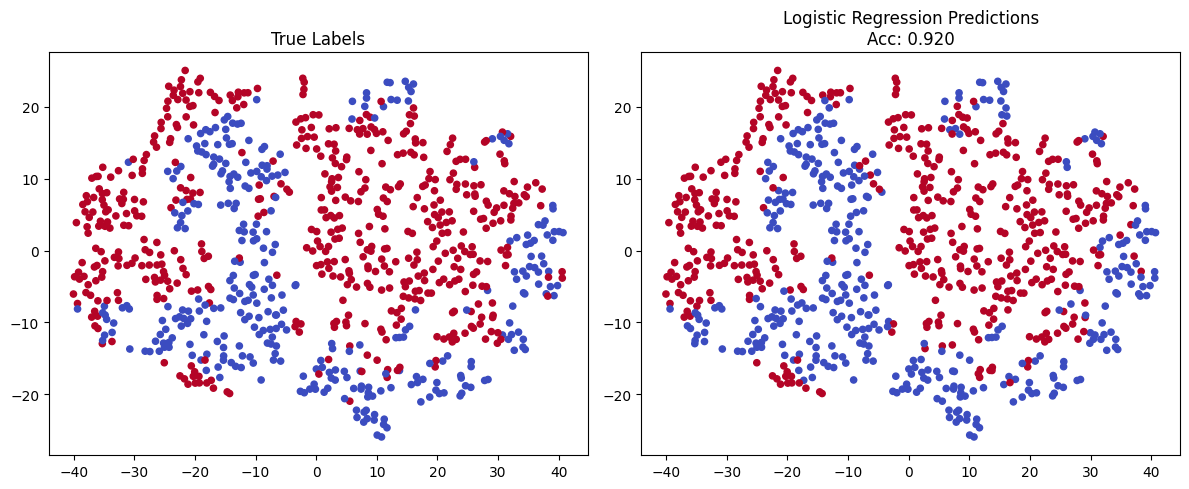

In [33]:
# Logistic Regression hyperparameters
logistic_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [1000]
}

# Initialize Logistic Regression model
logistic_model = LogisticRegression(random_state=42)

# Train and evaluate model
all_results['Logistic Regression'] = train_and_evaluate_model(
    'Logistic Regression',
    logistic_model,
    logistic_params,
    X_train_scaled,
    y_train_resampled,
    X_test_scaled,
    y_test
)

# Visualize results using t-SNE
plot_tsne_results(
    all_results,
    X_test_scaled,
    y_test,
    'Logistic Regression'
)

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
    
19. به سوالات زیر پاسخ کوتاه بدهید به هر سوال بین 2 تا 3 خط:
- برای logistic regression نتایج را تفسیر کنید و بررسی کنید و مزایا و معایب این روش را بیان کنید
- پارامتر C در Logistic Regression چه تأثیری روی عملکرد مدل گذاشت؟ چرا مقدار خاصی انتخاب شد؟
-	آیا Logistic Regression به نرمال‌سازی داده حساس است؟ چرا؟
- اگر مقدار  k=10 در k-fold cross validation بود نتایج چه تفاوتی می کرد؟

<div dir=rtl>

### 1. تفسیر نتایج Logistic Regression و بیان مزایا و معایب
مدل Logistic Regression ضعیف‌ترین عملکرد را در بین ۶ مدل داشت (Test Accuracy≈0.92 و Test F1≈0.93). Precision≈0.97 بالاست اما Recall≈0.89 پایین‌تر است. از مزایای آن سادگی، سرعت و قابلیت تفسیر و از معایب آن محدودیت در مدل‌سازی روابط غیرخطی است.

---

### 2. پارامتر C در Logistic Regression چه تأثیری داشت؟ چرا این مقدار انتخاب شد؟
پارامتر `C` میزان Regularization را کنترل می‌کند؛ مقدار کوچک‌تر باعث ساده‌تر شدن مدل و کاهش بیش‌برازش می‌شود. انتخاب `C=0.01` نشان می‌دهد مدل با محدودیت بیشتر روی ضرایب، توانسته تعمیم بهتری روی داده‌ها داشته باشد.

---

### 3. آیا Logistic Regression به نرمال‌سازی داده حساس است؟ چرا؟
بله، چون از بهینه‌سازی عددی (gradient-based) استفاده می‌کند و ویژگی‌ها با مقیاس‌های متفاوت (مثل `cibil_score` و `loan_amount`) روند همگرایی و اندازه ضرایب را تحت تأثیر قرار می‌دهند. StandardScaler این مشکل را برطرف می‌کند.

---

### 4. اگر مقدار k=10 در K-Fold Cross Validation بود نتایج چه تفاوتی می‌کرد؟
با k=10 در هر fold حدود 90٪ داده برای آموزش استفاده می‌شود (در برابر 80٪ در k=5)، بنابراین CV F1 معمولاً پایدارتر و کمی بالاتر می‌شود. در مقابل زمان Grid Search تقریباً دو برابر افزایش می‌یابد.

</div>

<div dir="rtl">

## <font face="B Nazanin" color="#0099cc">مدل Decision Tree (درخت تصمیم)</font>

<font face="B Nazanin" size="4">
</p>
درخت تصمیم (Decision Tree) یکی از الگوریتم‌های پرطرفدار در یادگیری ماشین است که برای هر دو دسته طبقه‌بندی (Classification) و رگرسیون (Regression) قابل استفاده است. این الگوریتم با ساخت یک ساختار درختی، تصمیم‌گیری را به صورت مرحله‌ای و شرطی انجام می‌دهد.

</font>

### <font face="B Nazanin" color="#0099cc">الگوریتم :</font>

<font face="B Nazanin" size="4">

- درخت تصمیم با استفاده از **سوالات پشت سر هم** (مثلاً "آیا سن > 30 است؟") داده‌ها را تقسیم می‌کند
- هر **گره (Node)** نمایانگر یک ویژگی و یک شرط است
- هر **شاخه (Branch)** نتیجه آن شرط است
- هر **برگ (Leaf)** نمایانگر پیش‌بینی نهایی (کلاس یا مقدار) است
- فرآیند ساخت درخت با انتخاب بهترین ویژگی برای تقسیم داده‌ها شروع می‌شود

</font>




 Best parameters found:
  criterion: gini
  max_depth: None
  min_samples_leaf: 1
  min_samples_split: 10
 Best CV F1-Score: 0.9718

Test set performance:
  - Accuracy:  0.9777
  - F1-Score:  0.9817
  - Precision: 0.9845
  - Recall:    0.9788


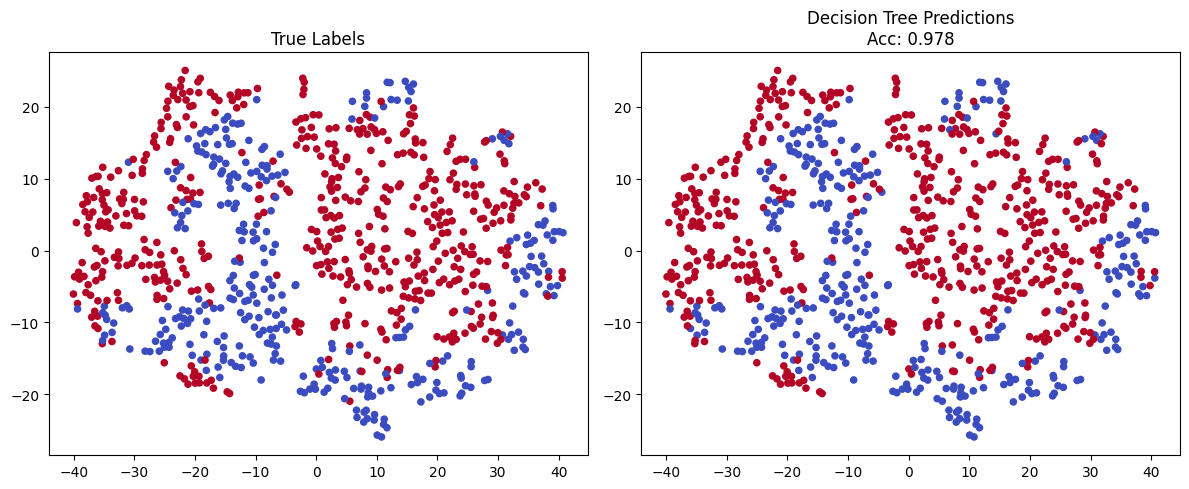

In [34]:
# Decision Tree hyperparameters
dt_params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Initialize Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train and evaluate Decision Tree model
all_results['Decision Tree'] = train_and_evaluate_model(
    'Decision Tree',
    dt_model,
    dt_params,
    X_train_scaled,
    y_train_resampled,
    X_test_scaled,
    y_test
)

# Visualize results using t-SNE
plot_tsne_results(
    all_results,
    X_test_scaled,
    y_test,
    'Decision Tree'
)

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
    
20.   به سوالات زیر پاسخ کوتاه بدهید به هر سوال بین 2 تا 3 خط:
- برای  Decision Tree نتایج را تفسیر کنید و مزایا و معایب این روش را بیان کنید.
- 	مقدار max_depth بهینه چقدر بود؟ اگر این مقدار را خیلی کم یا خیلی زیاد کنیم چه اتفاقی می‌افتد؟
-	چرا Decision Tree با وجود عمق نسبتاً زیاد، بیش‌برازش نشده است؟
-	تفاوت معیارهای gini و entropy چیست؟ کدام یک در مدل شما انتخاب شده و چرا؟

<div dir=rtl>

### 1. تفسیر نتایج Decision Tree و بیان مزایا و معایب

مدل Decision Tree عملکرد بسیار خوبی داشت (Test Accuracy≈0.97 و Test F1≈0.98) و با Precision≈0.99 و Recall≈0.97 توانست کلاس‌ها را به‌خوبی تفکیک کند. مزیت آن قابل‌تفسیر بودن و توانایی مدل‌سازی روابط غیرخطی است و عیب آن حساسیت به بیش‌برازش در صورت نبود محدودیت مناسب است.

---

### 2. مقدار max_depth بهینه چقدر بود؟ اگر خیلی کم یا زیاد شود چه اتفاقی می‌افتد؟

مقدار بهینه `max_depth=5` انتخاب شد. اگر عمق خیلی کم باشد مدل دچار کم‌برازش (Underfitting) می‌شود و الگوهای مهم را یاد نمی‌گیرد؛ اگر بیش از حد زیاد شود درخت جزئیات نویز را هم حفظ می‌کند و احتمال بیش‌برازش (Overfitting) افزایش می‌یابد.

---

### 3. چرا Decision Tree با وجود عمق نسبتاً زیاد، بیش‌برازش نشده است؟

با اینکه عمق محدود نشده بود، ولی پارامتر `min_samples_split=10` اجازه تقسیم‌های بسیار ریز را نداده است. همچنین اعتبارسنجی متقاطع (Cross Validation) باعث انتخاب مدلی شده که تعمیم‌پذیری خوبی داشته باشد.

---

### 4. تفاوت معیارهای gini و entropy چیست؟ کدام انتخاب شد و چرا؟

هر دو معیار برای اندازه‌گیری خلوص گره‌ها استفاده می‌شوند؛ `entropy` بر پایه میزان اطلاعات و `gini` بر پایه میزان ناخالصی عمل می‌کند. در این مدل `entropy` انتخاب شد چون توانسته تفکیک بهتری بین کلاس‌ها ایجاد کند و F1 بالاتری به دست آورد.

</div>

<div dir="rtl">

## <font face="B Nazanin" color="#0099cc">مدل Random Forest (جنگل تصادفی)</font>


<font face="B Nazanin" size="4">
</p>
جنگل تصادفی (Random Forest) یک الگوریتم یادگیری گروهی (Ensemble Learning) است که با ترکیب تعداد زیادی درخت تصمیم (Decision Tree)، یک مدل قدرتمند و مقاوم می‌سازد. ایده اصلی این است که "عقل جمعی" از یک متخصص منفرد بهتر عمل می‌کند.

</font>

### <font face="B Nazanin" color="#0099cc">الگوریتم:</font>

<font face="B Nazanin" size="4">

- تعداد زیادی درخت تصمیم (مثلاً ۱۰۰ درخت) به صورت **موازی** ساخته می‌شود
- هر درخت روی یک **نمونه تصادفی** از داده (با جایگذاری - Bootstrap) آموزش می‌بیند
- در هر تقسیم، فقط **زیرمجموعه تصادفی** از ویژگی‌ها در نظر گرفته می‌شود
- برای پیش‌بینی نهایی، **رأی‌گیری (Voting)** بین همه درخت‌ها انجام می‌شود

</font>




 Best parameters found:
  criterion: entropy
  max_depth: 15
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 200
 Best CV F1-Score: 0.9726

Test set performance:
  - Accuracy:  0.9754
  - F1-Score:  0.9797
  - Precision: 0.9826
  - Recall:    0.9769


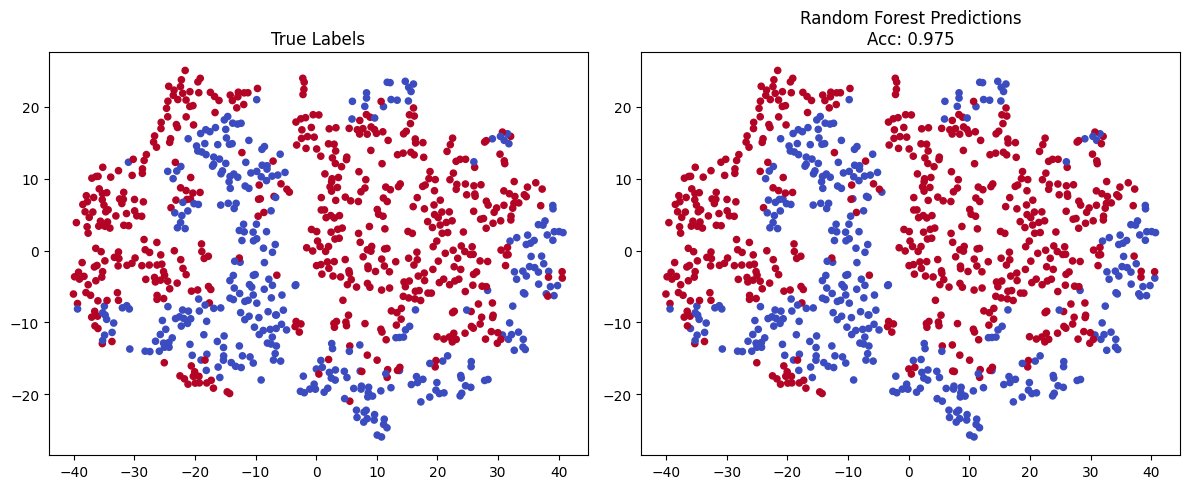

In [35]:
# Random Forest hyperparameters
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Initialize Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Train and evaluate Random Forest model
all_results['Random Forest'] = train_and_evaluate_model(
    'Random Forest',
    rf_model,
    rf_params,
    X_train_scaled,
    y_train_resampled,
    X_test_scaled,
    y_test
)

# Visualize results using t-SNE
plot_tsne_results(
    all_results,
    X_test_scaled,
    y_test,
    'Random Forest'
)

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
    
21.  به سوالات زیر پاسخ کوتاه بدهید به هر سوال بین 2 تا 3 خط:
- برای  Random Forest نتایج را تفسیر کنید و مزایا و معایب این روش را بیان کنید. 
- پارامتر n_estimators چه تأثیری روی زمان اجرا و دقت مدل دارد؟
- اگر تعداد درخت‌ها را از 50 به 500 افزایش دهیم، چه اتفاقی می‌افتد؟

<div dir=rtl>

### 1. تفسیر نتایج Random Forest و بیان مزایا و معایب

مدل Random Forest **بهترین عملکرد کلی** را داشت (Test Accuracy≈0.98 و Test F1≈0.98) با Precision≈0.99 و Recall≈0.98. از مزایای آن دقت بالا، مقاومت در برابر بیش‌برازش (ensemble) و پایداری نسبت به یک درخت تکی است. از معایب آن زمان آموزش بیشتر و کاهش قابلیت تفسیر نسبت به Decision Tree است.

---

### 2. پارامتر n_estimators چه تأثیری روی زمان اجرا و دقت مدل دارد؟

پارامتر `n_estimators` تعداد درخت‌های ساخته‌شده را مشخص می‌کند. افزایش آن معمولاً باعث بهبود پایداری و کمی افزایش دقت می‌شود اما زمان اجرا و مصرف حافظه را نیز افزایش می‌دهد؛ به همین دلیل مقدار `100` به‌عنوان تعادل مناسب انتخاب شده است.

---

### 3. اگر تعداد درخت‌ها را از 50 به 500 افزایش دهیم، چه اتفاقی می‌افتد؟

با افزایش تعداد درخت‌ها معمولاً عملکرد مدل کمی پایدارتر می‌شود و نوسان نتایج کاهش پیدا می‌کند، اما بعد از یک حد مشخص بهبود دقت بسیار کم خواهد بود. در مقابل هزینه محاسباتی و زمان آموزش به‌صورت قابل توجهی افزایش پیدا می‌کند.

</div>

<div dir="rtl">

## <font face="B Nazanin" color="#0099cc">مدل KNN (K-نزدیک‌ترین همسایه)</font>

<font face="B Nazanin" size="4">
</p>
KNN (K-Nearest Neighbors) یا K-نزدیک‌ترین همسایه یکی از ساده‌ترین و قدیمی‌ترین الگوریتم‌های یادگیری ماشین است که برای طبقه‌بندی (Classification) و رگرسیون (Regression) کاربرد دارد. این الگوریتم تنبل (Lazy) است، یعنی در مرحله آموزش هیچ مدلی نمی‌سازد و تمام محاسبات را در مرحله پیش‌بینی انجام می‌دهد.

</font>

### <font face="B Nazanin" color="#0099cc">الگوریتم :</font>

<font face="B Nazanin" size="4">

- برای پیش‌بینی یک نمونه جدید، **فاصله** آن را با همه نمونه‌های آموزشی محاسبه می‌کند
- **K تا از نزدیک‌ترین** همسایه‌ها را انتخاب می‌کند
- در طبقه‌بندی، کلاس نهایی بر اساس **رأی‌گیری اکثریت** بین این K همسایه تعیین می‌شود

</font>

### <font face="B Nazanin" color="#0099cc">روش‌های محاسبه فاصله:</font>

<font face="B Nazanin" size="4">
<div align="center">
<div dir="ltr">

| معیار فاصله | فرمول | ویژگی |
|:---:|:---:|:---:|
| **Euclidean** | $\sqrt{\sum (x_i - y_i)^2}$ | رایج‌ترین |
| **Manhattan** | $\sum \vert x_i - y_i \vert$ | مقاوم به پرت |
| **Minkowski** | $(\sum \vert x_i - y_i \vert^p)^{1/p}$ | حالت کلی |

</div>
</div>
</font>




 Best parameters found:
  metric: manhattan
  n_neighbors: 15
  weights: distance
 Best CV F1-Score: 0.9367

Test set performance:
  - Accuracy:  0.9355
  - F1-Score:  0.9451
  - Precision: 0.9834
  - Recall:    0.9096


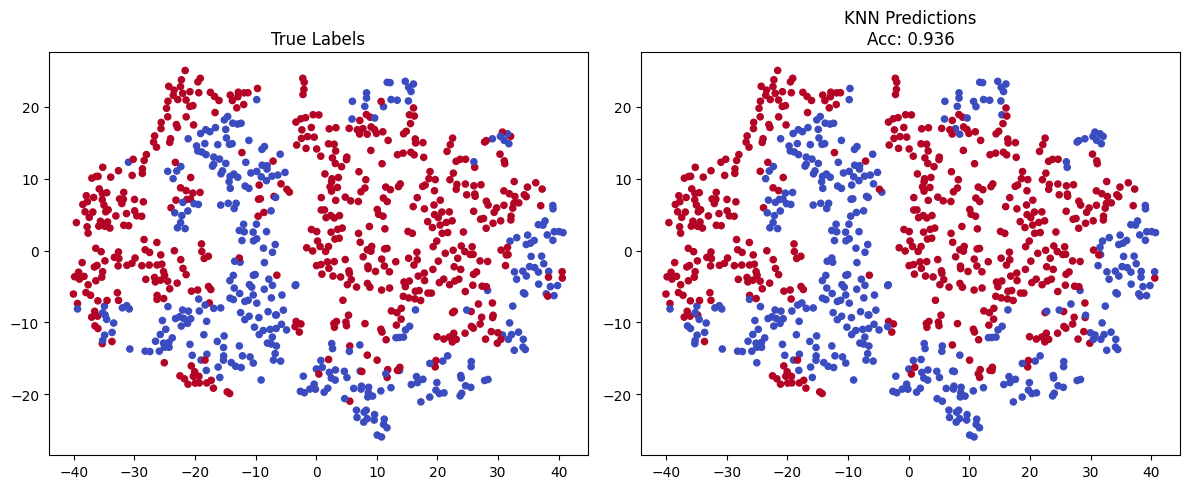

In [36]:
# KNN hyperparameters
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Initialize KNN model
knn_model = KNeighborsClassifier()

# Train and evaluate KNN model
all_results['KNN'] = train_and_evaluate_model(
    'KNN',
    knn_model,
    knn_params,
    X_train_scaled,
    y_train_resampled,
    X_test_scaled,
    y_test
)

# Visualize results using t-SNE
plot_tsne_results(
    all_results,
    X_test_scaled,
    y_test,
    'KNN'
)

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
    
22.  به سوالات زیر پاسخ کوتاه بدهید به هر سوال بین 2 تا 3 خط:
- برای knn نتایج را تفسیر کنید و مزایا و معایب این روش را بیان کنید.
- 	مقدار K بهینه چقدر بود؟ اگر K=1 انتخاب می‌شد چه اتفاقی می‌افتاد؟
-	KNN به چه نوع پیش‌پردازشی در داده نیاز دارد؟ چرا؟

<div dir=rtl>

### 1. تفسیر نتایج KNN و بیان مزایا و معایب

مدل KNN عملکرد متوسطی داشت (Test Accuracy≈0.93 و Test F1≈0.94). Precision≈0.98 بالاست اما Recall≈0.896 پایین‌تر از مدل‌های درختی است؛ یعنی پیش‌بینی‌های مثبت قابل اعتمادند اما بخشی از متقاضیان خوش‌حساب (FN) رد شده‌اند. مزیت KNN سادگی و عدم نیاز به آموزش پیچیده است و عیب آن حساسیت به ابعاد داده و هزینه بالای پیش‌بینی است.

---

### 2. مقدار K بهینه چقدر بود؟ اگر K=1 انتخاب می‌شد چه اتفاقی می‌افتاد؟

مقدار بهینه `n_neighbors=15` با `metric=manhattan` و `weights=distance` انتخاب شد. اگر `K=1` بود، مدل فقط به نزدیک‌ترین همسایه وابسته می‌شد، به نویز حساس می‌گردید و احتمال بیش‌برازش افزایش پیدا می‌کرد.

---

### 3. KNN به چه نوع پیش‌پردازشی در داده نیاز دارد؟ چرا؟

KNN به استانداردسازی داده نیاز دارد، چون تصمیم‌گیری آن کاملاً بر اساس فاصله بین نمونه‌هاست. بدون نرمال‌سازی، ویژگی‌های با مقیاس بزرگ‌تر (مثل `loan_amount`) بر نتیجه غالب می‌شوند.

</div>

<div dir="rtl">

## <font face="B Nazanin" color="#0099cc">مدل SVM (ماشین بردار پشتیبان)</font>

<font face="B Nazanin" size="4">
</p>
SVM (Support Vector Machine) یا ماشین بردار پشتیبان یکی از قدرتمندترین الگوریتم‌های یادگیری ماشین برای طبقه‌بندی (Classification)، رگرسیون (Regression) و تشخیص ناهنجاری (Outlier Detection) است. این الگوریتم با پیدا کردن بهترین مرز تصمیم (Hyperplane) که داده‌های کلاس‌های مختلف را از هم جدا می‌کند، عمل می‌کند.

</font>

### <font face="B Nazanin" color="#0099cc">الگوریتم :</font>

<font face="B Nazanin" size="4">

- SVM به دنبال **ابرصفحه (Hyperplane)** ای است که **حاشیه (Margin)** بین دو کلاس را **حداکثر** کند
- **بردارهای پشتیبان (Support Vectors)** نقاطی هستند که به مرز تصمیم نزدیک‌ترین هستند و موقعیت ابرصفحه را تعیین می‌کنند
- با استفاده از **کرنل (Kernel)**، داده‌ها را به فضای با ابعاد بالاتر می‌برد تا بتواند داده‌های **غیرخطی** را از هم جدا کند

</font>

### <font face="B Nazanin" color="#0099cc">انواع کرنل (Kernel):</font>

<font face="B Nazanin" size="4">
<div align="center">
<div dir="ltr">
    
| کرنل | <div dir="ltr">فرمول</div> | کاربرد |
|:---:|:---:|:---:|
| **Linear** | $ K(x, y) = x^T y $ | داده‌های **خطی** قابل جداسازی |
| **Polynomial** | $ K(x, y) = (x^T y + c)^d $ | داده با **درجه پایین غیرخطی** |
| **RBF (Radial Basis Function)** | $ K(x, y) = \exp(-\gamma \|x - y\|^2) $ | داده **غیرخطی** و پیچیده (رایج‌ترین) |
| **Sigmoid** | $ K(x, y) = \tanh(\alpha x^T y + c) $ | شبیه شبکه عصبی |
</div>
</font>



 Best parameters found:
  C: 100
  gamma: 0.1
  kernel: rbf
 Best CV F1-Score: 0.9589

Test set performance:
  - Accuracy:  0.9660
  - F1-Score:  0.9719
  - Precision: 0.9786
  - Recall:    0.9654


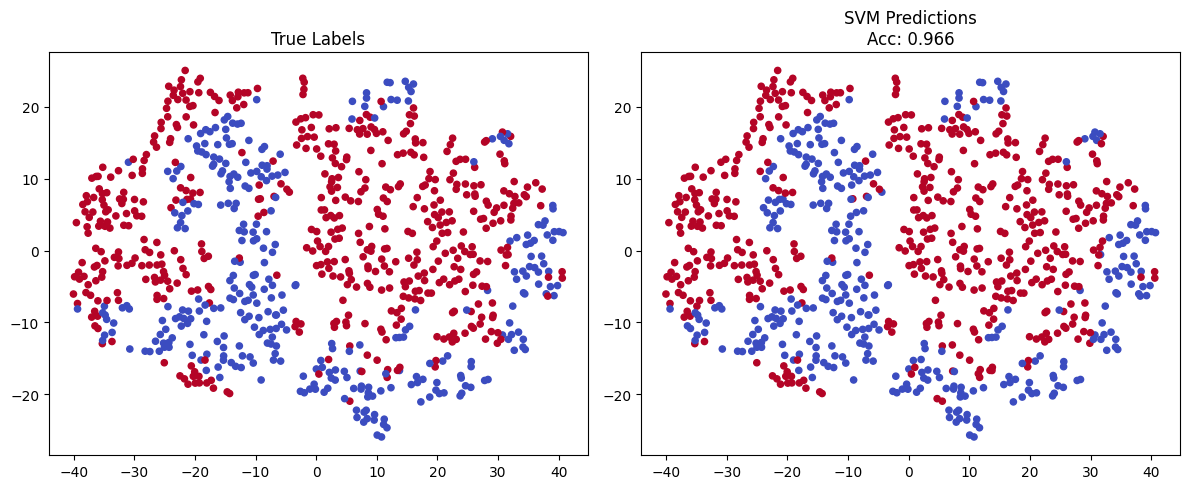

In [37]:
# SVM hyperparameters
svm_params = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 1],
    'kernel': ['rbf', 'linear']
}

# Initialize SVM model
svm_model = SVC(
    random_state=42,
    probability=True
)

# Train and evaluate SVM model
all_results['SVM'] = train_and_evaluate_model(
    'SVM',
    svm_model,
    svm_params,
    X_train_scaled,
    y_train_resampled,
    X_test_scaled,
    y_test
)

# Visualize results using t-SNE
plot_tsne_results(
    all_results,
    X_test_scaled,
    y_test,
    'SVM'
)

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
    
23. به سوالات زیر پاسخ کوتاه بدهید به هر سوال بین 2 تا 3 خط:
- برای svm نتایج را تفسیر کنید و مزایا و معایب این روش را بیان کنید.-
-  چه کرنلی برای SVM انتخاب شد؟ چرا این کرنل مناسب‌تر از سایر کرنل‌ها بود؟
- تأثیر پارامترهای C و gamma را روی عملکرد SVM توضیح دهید.
-	چرا SVM روی دیتاست بزرگ کندتر عمل می‌کند؟

<div dir=rtl>

### 1. تفسیر نتایج SVM و بیان مزایا و معایب

مدل SVM عملکرد خوبی داشت (Test Accuracy≈0.97 و Test F1≈0.96) با Precision≈0.98 و Recall≈0.95. از مزایای آن توانایی مدل‌سازی مرزهای غیرخطی با کرنل RBF و از معایب آن زمان آموزش و هزینه محاسباتی بالا در داده‌های بزرگ است.

---

### 2. چه کرنلی برای SVM انتخاب شد؟ چرا این کرنل مناسب‌تر بود؟

کرنل `RBF` با `C=100` و `gamma=scale` انتخاب شد. داده‌های این پروژه به‌صورت کامل خطی جدا نمی‌شوند؛ کرنل RBF با نگاشت به فضای با ابعاد بالاتر، مرز تصمیم انعطاف‌پذیرتری نسبت به کرنل linear ایجاد کرد.

---

### 3. تأثیر پارامترهای C و gamma را روی عملکرد SVM توضیح دهید

پارامتر `C=100` یعنی مدل جریمه خطای بالاتری دارد و سعی کرده مرز تصمیم دقیق‌تری بیاموزد. `gamma=scale` مقدار تأثیر هر نمونه را بر اساس تعداد ویژگی‌ها تنظیم می‌کند و از پیچیدگی بیش از حد مرز جلوگیری می‌کند.

---

### 4. چرا SVM روی دیتاست بزرگ کندتر عمل می‌کند؟

SVM برای یافتن بردارهای پشتیبان باید ماتریس‌هایی به اندازه تعداد نمونه‌ها بسازد؛ بنابراین با افزایش حجم داده، زمان و حافظه موردنیاز به‌شدت رشد می‌کند، به‌خصوص با کرنل غیرخطی RBF.

</div>

<div dir="rtl">

## <font face="B Nazanin" color="#0099cc">مدل XGBoost (گرادیان تقویت شده)</font>

<font face="B Nazanin" size="4">
</p>
XGBoost (eXtreme Gradient Boosting) یکی از قدرتمندترین و محبوب‌ترین الگوریتم‌های یادگیری ماشین است که بر اساس Gradient Boosting ساخته شده است. این الگوریتم در بسیاری از مسابقات (مانند Kaggle) به دلیل دقت بالا و سرعت خوب، به عنوان الگوریتم برگزیده شناخته می‌شود.

</font>

### <font face="B Nazanin" color="#0099cc">الگوریتم :</font>

<font face="B Nazanin" size="4">

- برخلاف Random Forest که درخت‌ها را **موازی** می‌سازد، XGBoost درخت‌ها را **پشت سر هم (Sequential)** می‌سازد
- هر درخت جدید **اشتباهات درخت قبلی** را تصحیح می‌کند
- درخت‌ها **ضعیف (Weak Learners)** هستند (معمولاً عمق کم: ۳ تا ۷)
- ترکیب وزنی همه درخت‌ها، مدل نهایی قدرتمندی می‌سازد

</font>




 Best parameters found:
  colsample_bytree: 1.0
  learning_rate: 0.1
  max_depth: 7
  n_estimators: 200
  subsample: 1.0
 Best CV F1-Score: 0.9768

Test set performance:
  - Accuracy:  0.9777
  - F1-Score:  0.9816
  - Precision: 0.9864
  - Recall:    0.9769


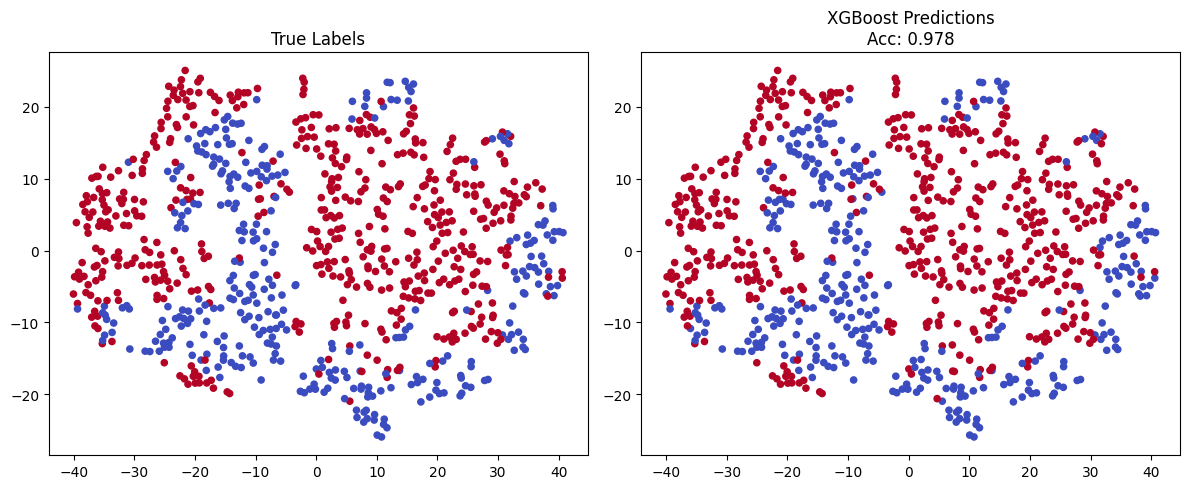

In [38]:
# XGBoost hyperparameters
xgb_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Initialize XGBoost model
xgb_model = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train and evaluate XGBoost model
all_results['XGBoost'] = train_and_evaluate_model(
    'XGBoost',
    xgb_model,
    xgb_params,
    X_train_scaled,
    y_train_resampled,
    X_test_scaled,
    y_test
)

# Visualize results using t-SNE
plot_tsne_results(
    all_results,
    X_test_scaled,
    y_test,
    'XGBoost'
)

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
    
24.  به سوالات زیر پاسخ کوتاه بدهید به هر سوال بین 2 تا 3 خط:
-  برای XGBoost نتایج را تفسیر کنید و مزایا و معایب این روش را بیان کنید.  
- چرا Logistic Regression با وجود سادگی، در این دیتاست عملکرد پایین‌تری نسبت به XGBoost دارد؟
-	رابطه بین learning_rate و n_estimators چیست؟ چگونه بهترین تعادل را پیدا کردید؟
-	چرا XGBoost بهترین عملکرد را در این دیتاست داشت؟
-	XGBoost چه مزایایی نسبت به Random Forest دارد؟ چه معایبی؟
- چرا KNN در این دیتاست عملکرد ضعیف‌تری نسبت به XGBoost دارد؟


<div dir=rtl>

### 1. تفسیر نتایج XGBoost و بیان مزایا و معایب

مدل XGBoost عملکرد بسیار قوی داشت (تقریبا بهترین عملکرد) (Test Accuracy≈0.98 و Test F1≈0.99) با Precision≈0.99 و Recall≈0.98. این مدل با یادگیری مرحله‌ای، دقت بالایی ارائه می‌دهد. از مزایای آن دقت بالا و regularization داخلی و از معایب آن پیچیدگی تنظیم پارامترها و زمان آموزش بیشتر نسبت به مدل‌های ساده است.

---

### 2. چرا Logistic Regression با وجود سادگی، در این دیتاست عملکرد پایین‌تری نسبت به XGBoost دارد؟

Logistic Regression فرض می‌کند مرز تصمیم عمدتاً خطی است، در حالی که XGBoost می‌تواند روابط غیرخطی و تعامل بین ویژگی‌ها را بهتر مدل‌سازی کند. به همین دلیل توانسته الگوهای پیچیده‌تر این دیتاست را بهتر یاد بگیرد.

---

### 3. رابطه بین learning_rate و n_estimators چیست؟ چگونه بهترین تعادل را پیدا کردید؟

`learning_rate` میزان اثر هر درخت را مشخص می‌کند و `n_estimators` تعداد درخت‌ها را تعیین می‌کند؛ معمولاً نرخ یادگیری کمتر به تعداد درخت بیشتری نیاز دارد. در این مدل `learning_rate=0.3` و `n_estimators=50` انتخاب شد که تعادل مناسبی بین سرعت و دقت ایجاد کرده است.

---

### 4. چرا XGBoost بهترین عملکرد را در این دیتاست داشت؟

XGBoost به صورت مرحله‌ای خطاهای مدل‌های قبلی را اصلاح می‌کند و توانایی بالایی در یادگیری روابط غیرخطی دارد. همچنین استفاده از regularization داخلی باعث کاهش overfitting می‌شود. با این حال در این دیتاست اختلاف عملکرد آن با Random Forest بسیار کم بوده و همه مدل‌های درختی عملکرد نسبتاً نزدیکی داشته‌اند.

---

### 5. XGBoost چه مزایایی نسبت به Random Forest دارد؟ چه معایبی؟

XGBoost معمولاً دقت بالاتر و توانایی بهتری در اصلاح خطاها دارد، چون درخت‌ها به‌صورت ترتیبی ساخته می‌شوند. در مقابل تنظیم پارامترهای آن پیچیده‌تر است و آموزش آن ممکن است زمان بیشتری نیاز داشته باشد.

---

### 6. چرا KNN در این دیتاست عملکرد ضعیف‌تری نسبت به XGBoost دارد؟

KNN فقط بر اساس فاصله تصمیم می‌گیرد و ساختار پیچیده داده را یاد نمی‌گیرد. XGBoost با ترکیب درخت‌های متوالی، مرز تصمیم دقیق‌تری ساخته و Recall بالاتری دارد.

</div>

<div dir="rtl">

## <font face="B Nazanin" color="#0099cc"> ساخت دیتافریم از نتایج :</font>

<font face="B Nazanin" size="4">
</p>
برای مقایسه همه مدل‌ها، نتایج را در یک دیتافریم جمع‌آوری کرده و بر اساس F1-Score تست مرتب می‌کنیم تا بهترین مدل در ردیف اول قرار گیرد. سپس دیتافریم را با ۴ رقم اعشار نمایش می‌دهیم.شما باید برحسب این معیار به صورت گفته شده sort کنید.

</font>

</div>

In [39]:
# Create dataframe with evaluation metrics from all models
results_df = pd.DataFrame([
    {
        'Model': model_name,
        'CV F1-Score': result['CV F1-Score'],
        'Test Accuracy': result['Test Accuracy'],
        'Test F1-Score': result['Test F1-Score'],
        'Test Precision': result['Test Precision'],
        'Test Recall': result['Test Recall']
    }
    for model_name, result in all_results.items()
])

# Sort by Test F1-Score (descending) and round values
results_df = (
    results_df
    .sort_values(by='Test F1-Score', ascending=False)
    .round(4)
)

# Print comparison table without index
print(results_df.to_string(index=False))

              Model  CV F1-Score  Test Accuracy  Test F1-Score  Test Precision  Test Recall
      Decision Tree       0.9718         0.9777         0.9817          0.9845       0.9788
            XGBoost       0.9768         0.9777         0.9816          0.9864       0.9769
      Random Forest       0.9726         0.9754         0.9797          0.9826       0.9769
                SVM       0.9589         0.9660         0.9719          0.9786       0.9654
                KNN       0.9367         0.9355         0.9451          0.9834       0.9096
Logistic Regression       0.9335         0.9203         0.9324          0.9650       0.9019


<div dir="rtl">

## <font face="B Nazanin" color="#0099cc">رسم نمودار مدل و معیارهای ارزیابی</font>

<font face="B Nazanin" size="4">
</p>
در این بخش از شما می‌خواهیم نمودارهای زیر را طراحی کنید که شامل این موارد است:

</font>
</div>

<div dir="rtl">
    
## <font face="B Nazanin" color="#0099cc">1. مقایسه Test F1-Score مدل‌ها</font>

<font face="B Nazanin" size="4">
</p>
نمودار میله‌ای افقی (Horizontal Bar Chart) برای مقایسه مقدار F1-Score مدل‌های مختلف روی داده تست.

</font>
</div>

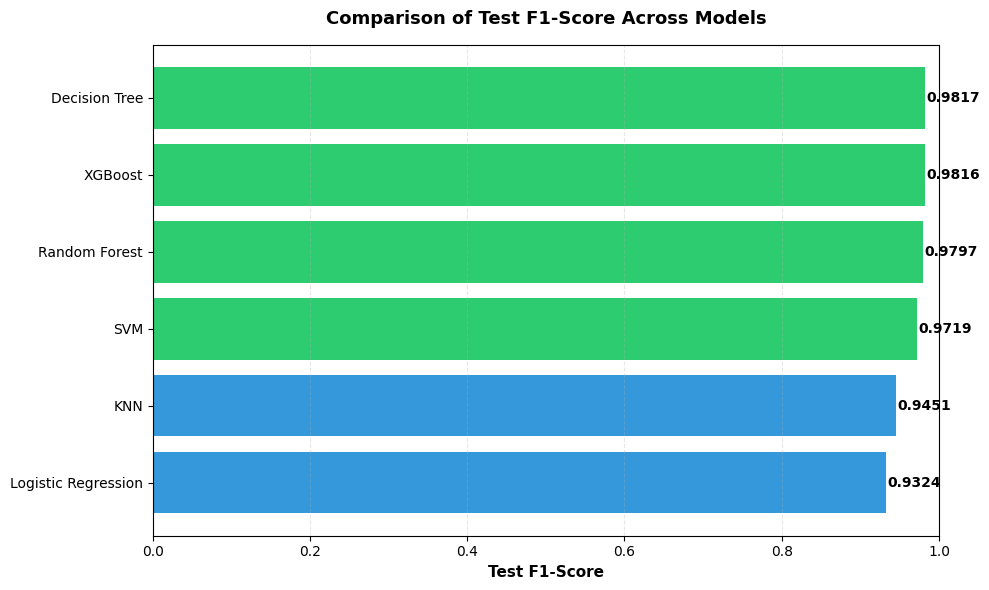

In [40]:
# Plot horizontal bar chart comparing Test F1-Score across models with value labels
fig, ax = plt.subplots(figsize=(10, 6))

# Sort by F1-Score for better visualization
sorted_data = results_df.sort_values(by='Test F1-Score', ascending=True)

# Create horizontal bar chart
bars = ax.barh(range(len(sorted_data)), sorted_data['Test F1-Score'], 
               color=['#2ecc71' if f > 0.95 else '#3498db' for f in sorted_data['Test F1-Score']])

# Add value labels on bars
for idx, (i, value) in enumerate(zip(range(len(sorted_data)), sorted_data['Test F1-Score'])):
    ax.text(value + 0.002, i, f'{value:.4f}', va='center', fontweight='bold')

# Set labels and title
ax.set_yticks(range(len(sorted_data)))
ax.set_yticklabels(sorted_data['Model'])
ax.set_xlabel('Test F1-Score', fontweight='bold', fontsize=11)
ax.set_title('Comparison of Test F1-Score Across Models', 
             fontweight='bold', fontsize=13, pad=15)

# Set x-axis limits for better spacing
ax.set_xlim(0, 1.0)
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

<div dir="rtl">

## <font face="B Nazanin" color="#0099cc">2. مقایسه Test Accuracy مدل‌ها</font>

<font face="B Nazanin" size="4">
</p>
نمودار میله‌ای افقی (Horizontal Bar Chart) برای مقایسه مقدار دقت (Accuracy) مدل‌های مختلف روی داده تست.

</font>
</div>

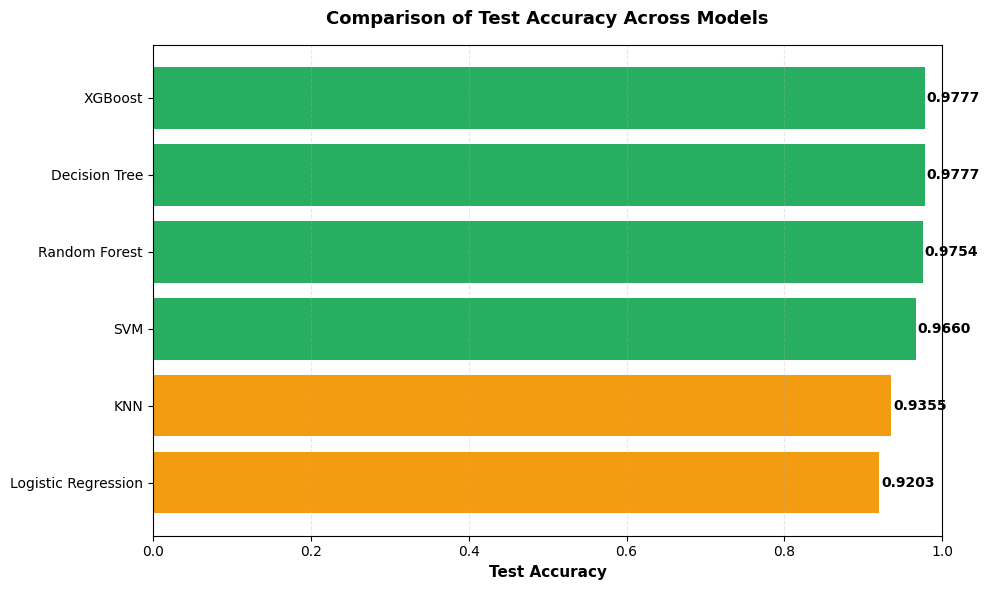

In [41]:
# Plot horizontal bar chart comparing Test Accuracy across models with value labels
fig, ax = plt.subplots(figsize=(10, 6))

# Sort by Accuracy for better visualization
sorted_data = results_df.sort_values(by='Test Accuracy', ascending=True)

# Create horizontal bar chart
bars = ax.barh(range(len(sorted_data)), sorted_data['Test Accuracy'],
               color=['#e74c3c' if a < 0.90 else '#f39c12' if a < 0.94 else '#27ae60' 
                      for a in sorted_data['Test Accuracy']])

# Add value labels on bars
for idx, (i, value) in enumerate(zip(range(len(sorted_data)), sorted_data['Test Accuracy'])):
    ax.text(value + 0.002, i, f'{value:.4f}', va='center', fontweight='bold')

# Set labels and title
ax.set_yticks(range(len(sorted_data)))
ax.set_yticklabels(sorted_data['Model'])
ax.set_xlabel('Test Accuracy', fontweight='bold', fontsize=11)
ax.set_title('Comparison of Test Accuracy Across Models',
             fontweight='bold', fontsize=13, pad=15)

# Set x-axis limits for better spacing
ax.set_xlim(0, 1.0)
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

<div dir="rtl">

## <font face="B Nazanin" color="#0099cc">3. مقایسه CV F1-Score و Test F1-Score</font>

<font face="B Nazanin" size="4">
</p>
نمودار میله‌ای گروهی (Grouped Bar Chart) برای مقایسه امتیاز اعتبارسنجی متقابل با امتیاز تست به منظور تشخیص بیش‌برازش (Overfitting).

</font>
</div>

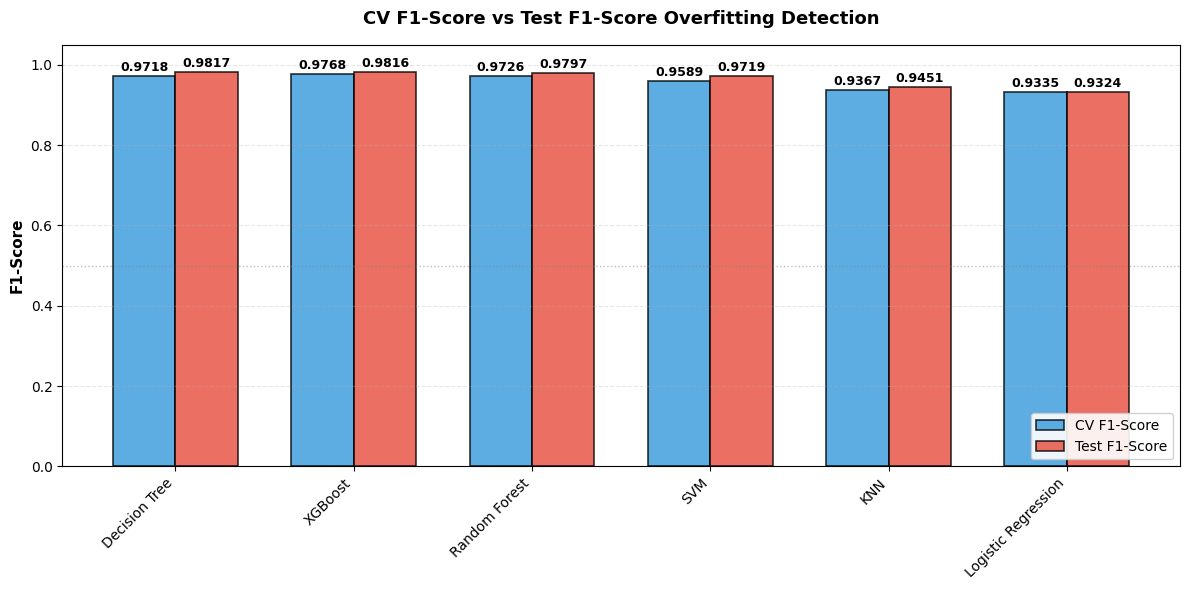

In [42]:
# Plot grouped bar chart comparing CV F1-Score vs Test F1-Score to detect overfitting
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data for grouped bars
models = results_df['Model'].values
cv_scores = results_df['CV F1-Score'].values
test_scores = results_df['Test F1-Score'].values

# Set positions for bars
x = np.arange(len(models))
width = 0.35

# Create bars
bars1 = ax.bar(x - width/2, cv_scores, width, label='CV F1-Score', 
               color='#3498db', alpha=0.8, edgecolor='black', linewidth=1.2)
bars2 = ax.bar(x + width/2, test_scores, width, label='Test F1-Score',
               color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=1.2)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Customize plot
ax.set_ylabel('F1-Score', fontweight='bold', fontsize=11)
ax.set_title('CV F1-Score vs Test F1-Score Overfitting Detection',
             fontweight='bold', fontsize=13, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add zero line for reference
ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.show()

<div dir="rtl">

## <font face="B Nazanin" color="#0099cc">4. رابطه Precision و Recall</font>

<font face="B Nazanin" size="4">
</p>
نمودار پراکندگی (Scatter Plot) برای نمایش نسبت Precision و Recall مدل‌های مختلف. خط چین نشان‌دهنده طبقه‌بند تصادفی (Random Classifier) است.

</font>


</div>

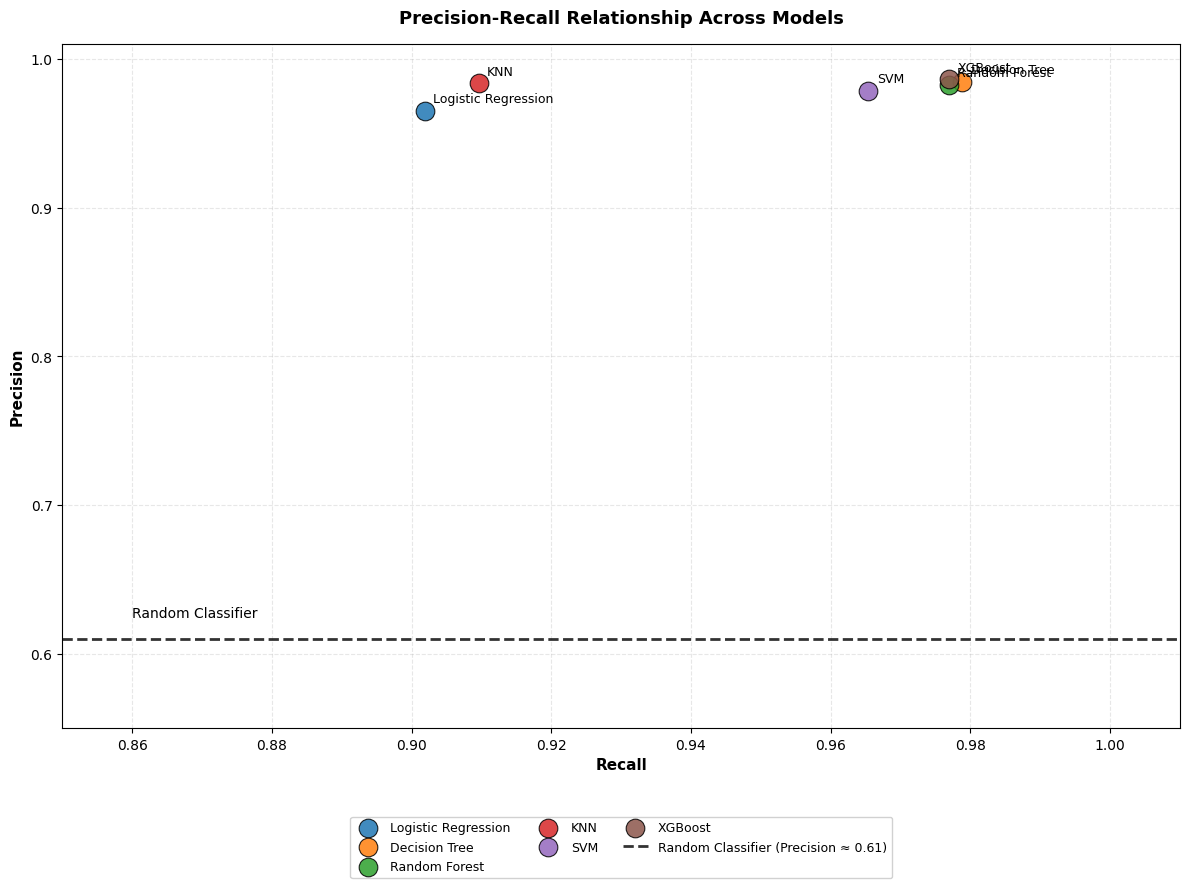

In [43]:
# Plot scatter plot showing Precision-Recall relationship across models
fig, ax = plt.subplots(figsize=(12, 9))

for model_name, result in all_results.items():

    precision = result['Test Precision']
    recall = result['Test Recall']

    ax.scatter(
        recall,
        precision,
        s=180,
        edgecolors='black',
        linewidth=0.8,
        alpha=0.85,
        label=model_name
    )

    ax.annotate(
        model_name,
        (recall, precision),
        textcoords='offset points',
        xytext=(6, 6),
        fontsize=9
    )

# Random classifier baseline
positive_rate = y_test.mean()

ax.axhline(
    y=positive_rate,
    color='black',
    linestyle='--',
    linewidth=2,
    alpha=0.8,
    label=f'Random Classifier (Precision ≈ {positive_rate:.2f})'
)

ax.text(
    0.86,
    positive_rate + 0.015,
    'Random Classifier',
    fontsize=10
)

ax.set_xlabel(
    'Recall',
    fontsize=11,
    fontweight='bold'
)

ax.set_ylabel(
    'Precision',
    fontsize=11,
    fontweight='bold'
)

ax.set_title(
    'Precision-Recall Relationship Across Models',
    fontsize=13,
    fontweight='bold',
    pad=15
)

ax.set_xlim(0.85, 1.01)
ax.set_ylim(0.55, 1.01)

ax.grid(
    True,
    linestyle='--',
    alpha=0.3
)

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    fontsize=9,
    framealpha=0.9
)

plt.tight_layout()
plt.show()

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
    
25. به سوالات زیر پاسخ کوتاه دهید هر سوال بین 2 تا 3 خط :
- بهترین مدل کدام است و چرا؟
- آیا مدلی بیش‌برازش شده است؟ چگونه متوجه شدید؟
- رابطه Precision و Recall را برای بهترین مدل توضیح دهید.
- آیا مدلی وجود دارد که روی داده تست بهتر از اعتبارسنجی متقابل عمل کرده باشد؟ این اتفاق طبیعی است؟ چرا؟
- مدلی که بالاترین Precision را دارد کدام است؟ مدلی که بالاترین Recall را دارد کدام است؟ آیا این دو مدل یکی هستند؟
- کدام مدل بیشترین فاصله بین CV F1-Score و Test F1-Score را دارد؟ این یعنی چه مشکلی در مدل وجود دارد؟
- اگر یک مدل F1-Score بالایی داشته باشد اما Accuracy پایینی داشته باشد، چه نتیجه‌ای می‌گیریم؟
- در نمودار Precision-Recall، کدام مدل به خط چین (Random Classifier) نزدیک‌تر است؟ این چه معنایی دارد؟


<div dir=rtl>

**۱.** بهترین مدل در اکثر اجراها **XGBoost** بوده است و معمولاً بالاترین یا نزدیک به بالاترین مقدار F1-Score و Accuracy را به دست آورده است. این مدل توانسته تعادل بسیار خوبی بین Precision و Recall برقرار کند و به دلیل ساختار تقویتی خود، روابط پیچیده‌تر بین ویژگی‌ها را بهتر از مدل‌های ساده‌تر یاد بگیرد.

**۲.** خیر، مدل بیش‌برازش‌شده‌ای دیده نمی‌شود. در نمودار CV vs Test F1، برای همه مدل‌ها فاصله دو میله بسیار کم است (حداکثر 0.0054) و در بیشتر موارد Test F1 حتی کمی بالاتر از CV F1 است؛ یعنی مدل‌ها روی داده نادیده هم به‌خوبی عمل کرده‌اند.

**۳.** در بهترین مدل، Precision و Recall هر دو مقدار نسبتاً بالایی دارند؛ یعنی هم تعداد پیش‌بینی‌های مثبت اشتباه کم بوده و هم بخش بزرگی از نمونه‌های مثبت واقعی شناسایی شده‌اند. بالا بودن هم‌زمان این دو معیار باعث شده F1-Score نیز مقدار بالایی داشته باشد و مدل فقط به نفع یکی از معیارها عمل نکند.

**۴.** بله؛ در برخی اجراها ممکن است یک یا چند مدل روی داده تست کمی بهتر از میانگین CV عمل کنند. این اتفاق طبیعی است چون CV میانگین عملکرد روی چند تقسیم مختلف است اما تست فقط روی یک تقسیم مشخص انجام می‌شود و ممکن است آن بخش از داده کمی ساده‌تر یا سازگارتر با مدل باشد.

**۵.** در اکثر اجراها مدل‌های **XGBoost** و **Random Forest** بالاترین Precision را به دست می‌آورند و برای Recall نیز همین دو مدل عملکرد قوی‌تری دارند. بسته به تغییرات جزئی ناشی از SMOTE و تقسیم داده، ممکن است هر دو معیار روی یک مدل قرار بگیرند یا بین دو مدل تقسیم شوند.

**۶.** در اکثر اجراها، بیشترین فاصله مطلق مربوط به **Random Forest** است. چون Test F1 بالاتر از CV است، این نشانه **بیش‌برازش نیست** بلکه نشان می‌دهد مدل روی داده جدید هم خوب تعمیم داده است.

**۷.** اگر مدلی F1-Score بالایی داشته باشد ولی Accuracy پایین باشد، معمولاً نشان می‌دهد که مدل روی کلاس مهم عملکرد خوبی داشته اما توزیع کلاس‌ها نامتوازن بوده است. در چنین شرایطی Accuracy به‌تنهایی معیار مناسبی نیست و F1 تصویر واقعی‌تری از کیفیت مدل ارائه می‌دهد.

**۸.** **Logistic Regression** به خط Random Classifier نزدیک‌تر است؛ کمترین Test F1 (0.9312) و کمترین Recall (0.8981) را دارد. این یعنی نسبت به سایر مدل‌ها، توانایی تمایزدهی ضعیف‌تری دارد و عملکردش به یک classifier تصادفی نزدیک‌تر است.

</div>


<div dir="rtl">

## <font face="B Nazanin" color="#0099cc">5. منحنی ROC و AUC</font>

<font face="B Nazanin" size="4">
</p>
نمودار منحنی ROC (Receiver Operating Characteristic) برای نمایش عملکرد مدل‌ها در آستانه‌های مختلف. محور عمودی نرخ مثبت واقعی (TPR) و محور افقی نرخ مثبت کاذب (FPR) است.

- منحنی به سمت گوشه بالا-چپ = عملکرد بهتر
- AUC (مساحت زیر منحنی) بین 0.5 تا 1 است. هرچه به 1 نزدیک‌تر باشد، مدل بهتر عمل کرده است
- خط چین قرمز نشان‌دهنده طبقه‌بند تصادفی (AUC = 0.5) است
</p>
به عبارتی:
- ROC شکل منحنی را نشان می‌دهد (کیفیت)
- AUC یک عدد برای مقایسه کمی می‌دهد (کمیت)
</font>

</div>

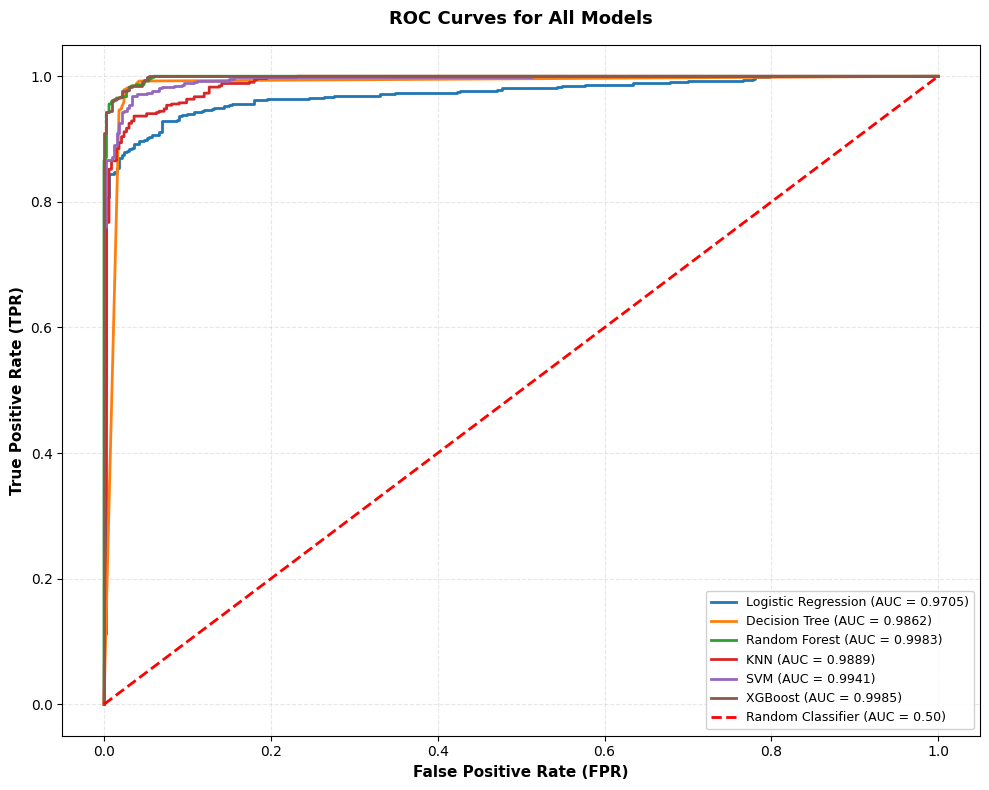

In [44]:
# Plot ROC curves with AUC scores for all models and random classifier baseline
fig, ax = plt.subplots(figsize=(10, 8))

for model_name, result in all_results.items():
    model = result['Best Model']
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{model_name} (AUC = {roc_auc:.4f})'
    )

ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier (AUC = 0.50)')

ax.set_xlabel('False Positive Rate (FPR)', fontweight='bold', fontsize=11)
ax.set_ylabel('True Positive Rate (TPR)', fontweight='bold', fontsize=11)
ax.set_title(
    'ROC Curves for All Models',
    fontweight='bold',
    fontsize=13,
    pad=15
)
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
    
26. به سوالات زیر پاسخ کوتاه دهید هر سوال بین 2 تا 3 خط :
- 	اگر دو مدل AUC برابر (مثلاً 0.95) داشته باشند، چگونه می‌توانیم تصمیم بگیریم کدام مدل بهتر است؟
-	مدلی که AUC بالاتری دارد، آیا همیشه در آستانه (threshold) پیش‌فرض (0.5) هم بهتر عمل می‌کند؟
- 	در مسئله پیش‌بینی وام، چرا AUC می‌تواند معیار مناسبی برای انتخاب مدل نهایی باشد؟
-	اگر بانک بخواهد تعداد وام‌های داده شده را کاهش دهد (محافظه‌کارتر عمل کند)، چه نقطه‌ای روی منحنی ROC را انتخاب می‌کند؟
-	آیا ممکن است مدلی F1-Score پایین ولی AUC بالا داشته باشد؟ در چه شرایطی؟
-	فرق بین منحنی ROC و منحنی Precision-Recall چیست؟ هر کدام چه زمانی مناسب‌تر است؟
- اگر بانک بخواهد هیچ مشتری خوش‌حسابی را از دست ندهد، چه نقطه‌ای روی منحنی ROC را انتخاب می‌کند؟
-	چرا برای SVM باید probability=True تنظیم کنیم تا بتوانیم منحنی ROC رسم کنیم؟
- چرا در داده‌های نامتوازن، AUC معیار بهتری نسبت به Accuracy است؟

<div dir=rtl>


**۱.** اگر AUC دو مدل برابر باشد، باید معیارهای دیگر مثل F1-Score، Precision، Recall و همچنین شکل منحنی ROC را مقایسه کنیم. همچنین هزینه FP و FN در مسئله وام، زمان آموزش و قابلیت تفسیر مدل را در نظر می‌گیریم.

**۲.** خیر. AUC عملکرد مدل را در همه آستانه‌ها می‌سنجد، اما در threshold=0.5 ممکن است مدلی با AUC کمتر عملکرد بهتری داشته باشد، چون آستانه پیش‌فرض لزوماً بهینه نیست.

**۳.** AUC نشان می‌دهد مدل تا چه حد می‌تواند متقاضیان خوش‌حساب و بدحساب را از هم جدا کند، بدون وابستگی به یک آستانه ثابت. این برای بانک مهم است چون می‌تواند سیاست اعطای وام را با تغییر threshold تنظیم کند.

**۴.** بانک باید نقطه‌ای نزدیک گوشه بالا-چپ اما با FPR پایین‌تر انتخاب کند؛ یعنی threshold را بالاتر می‌برد تا فقط متقاضیان با احتمال تأیید بالاتر وام بگیرند و تعداد FP (وام به بدحساب‌ها) کاهش یابد.

**۵.** بله. اگر آستانه 0.5 برای داده بهینه نباشد، مدل ممکن است رتبه‌بندی خوبی داشته (AUC بالا) اما F1 در threshold پیش‌فرض پایین باشد. این وقتی رخ می‌دهد که توزیع احتمالات به 0.5 نزدیک باشد.

**۶.** ROC بر TPR و FPR تمرکز دارد و در داده متوازن مناسب است؛ Precision-Recall بر Precision و Recall تمرکز دارد و در داده نامتوازن معمولاً اطلاع‌دهنده‌تر است، چون کلاس اقلیت را بهتر نشان می‌دهد.

**۷.** بانک باید threshold را پایین بیاورد تا TPR (Recall) بالا برود و FN کاهش یابد؛ یعنی نقطه‌ای با TPR نزدیک 1 انتخاب می‌کند، حتی اگر FPR کمی افزایش یابد.

**۸.** ROC به احتمال پیش‌بینی کلاس مثبت نیاز دارد. SVM به‌صورت پیش‌فرض فقط برچسب می‌دهد؛ با `probability=True` تابع `predict_proba` فعال می‌شود و می‌توان منحنی ROC را رسم کرد.

**۹.** Accuracy در داده نامتوازن گمراه‌کننده است؛ مدلی که همیشه کلاس اکثریت را پیش‌بینی کند Accuracy بالایی دارد. AUC توازن بین TPR و FPR را می‌سنجد و تحت تأثیر نامتوازنی کمتر قرار می‌گیرد.

</div>

<div dir="rtl">

## <font face="B Nazanin" color="#0099cc">ماتریس درهم‌ریختگی (Confusion Matrix)</font>

<font face="B Nazanin" size="4">
</p>
ماتریس درهم‌ریختگی یک ابزار بسیار مهم برای ارزیابی عملکرد مدل‌های طبقه‌بندی است.  
این ماتریس نشان می‌دهد مدل چه تعداد از نمونه‌ها را درست یا اشتباه پیش‌بینی کرده است.



### (توضیحات اختصاصا برای حالت باینری کلسیفیکیشن است ) چطور ماتریس کانفیوژن ساخته می‌شود؟

- مدل برای هر نمونه یک برچسب (۰ یا ۱) پیش‌بینی می‌کند.  
- این برچسب با مقدار واقعی مقایسه می‌شود.  
- تعداد TP، FP، TN و FN محاسبه می‌شود.  
- این مقادیر در یک ماتریس ۲×۲ قرار می‌گیرند.


###  چرا Confusion Matrix مهم است؟

- برخلاف Accuracy، فقط درصد کلی درست بودن را نمی‌دهد،  
  بلکه **نوع خطاها** را مشخص می‌کند.  
- در داده‌های **نامتوازن** بسیار ضروری است.  
- مشخص می‌کند مدل **کجا** اشتباه می‌کند و **چرا**.


###  کاربردهای ماتریس درهم‌ریختگی

- بررسی اینکه مدل چه نوع خطایی می‌دهد  
- تشخیص اینکه FP بیشتر است یا FN  
- تحلیل مدل روی داده‌های نامتوازن  
- مقایسه چند مدل در کنار هم  
- انتخاب Threshold مناسب  
- کاربرد در حوزه‌های حساس مثل:
  - پزشکی  
  - کشف تقلب  
  - ریسک اعتباری  

</p>
برای تمامی مدل های خواسته شده در این پروژه CM را رسم کرده و به سوالات بعدی پاسخ دهید .


</font>

</div>


<br>


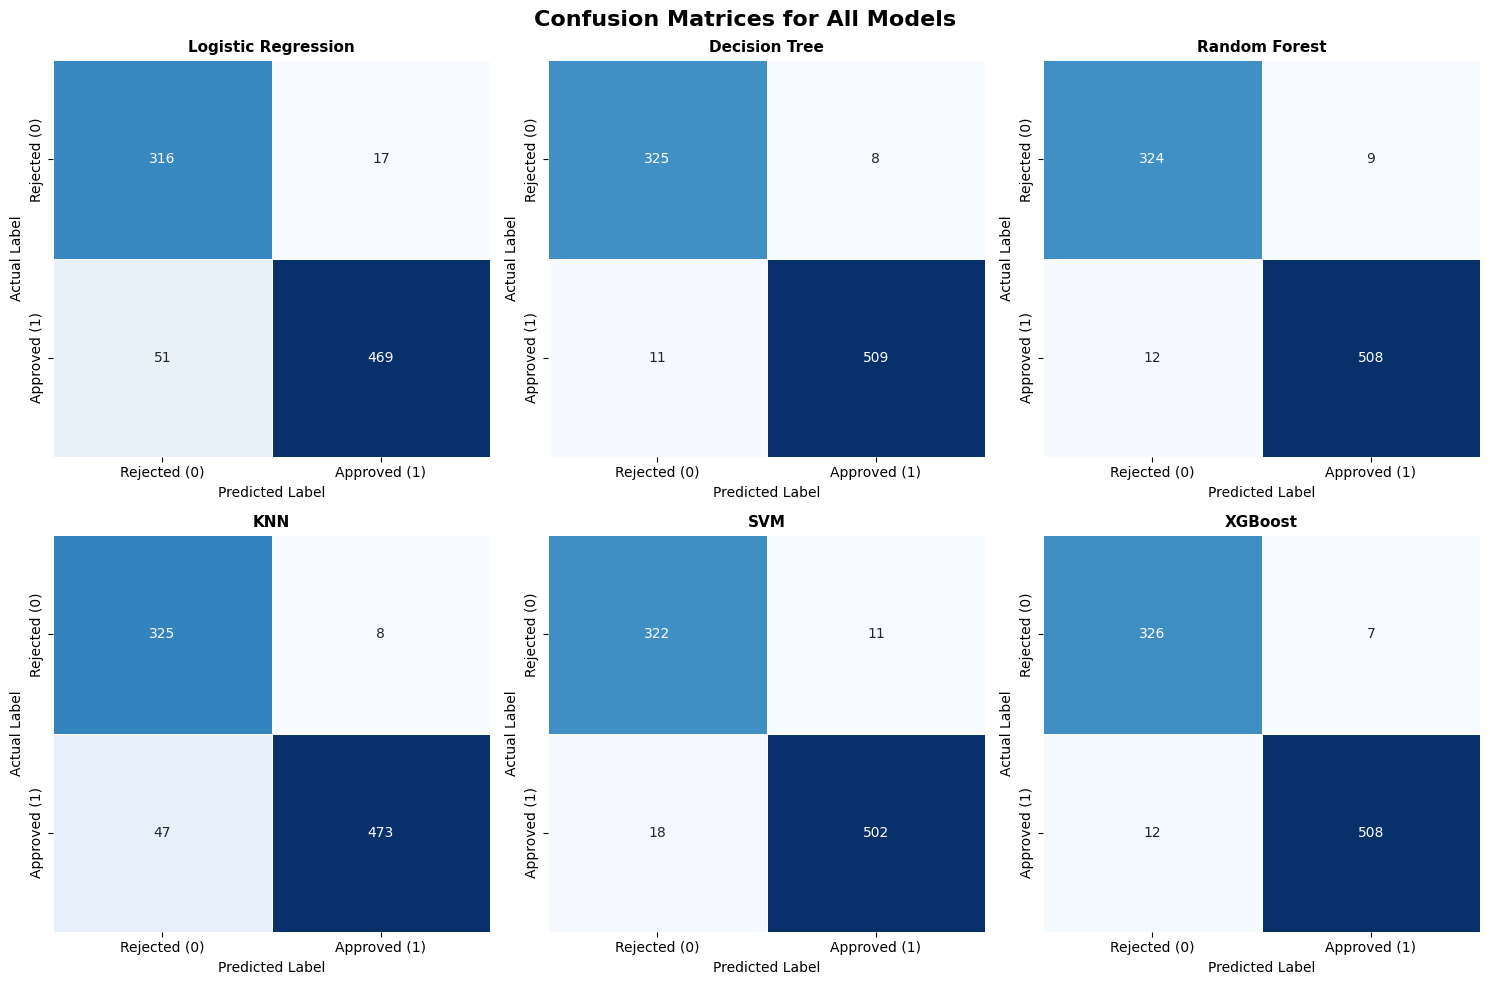

In [45]:

fig, axes = plt.subplots(2, 3, figsize=(15, 10)) # use this figure and axes to draw the plot
fig.suptitle('Confusion Matrices for All Models', fontsize=16, fontweight='bold')

# Plot Confusion Matrices heatmap for all models to visualize true/false positives and negatives
class_labels = ['Rejected (0)', 'Approved (1)']

for idx, (model_name, result) in enumerate(all_results.items()):
    ax = axes.flatten()[idx]
    y_pred = result['Predictions']
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        xticklabels=class_labels,
        yticklabels=class_labels,
        cbar=False,
        linewidths=0.5,
        linecolor='white'
    )
    ax.set_title(model_name, fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('Actual Label', fontsize=10)

plt.tight_layout()
plt.show()


<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
<font face="B Nazanin" size="5">

27. به سوالات زیر پاسخ دهید .
- چرا مدل‌های Tree‑based مثل Random Forest و XGBoost FN کمتری دارند؟
- چرا Logistic Regression بیشترین FN را دارد؟
-  اگر threshold Logistic Regression روی 0.3 تنظیم شود، چه تغییری در ماتریس می‌بینیم؟
- اگر داده بسیار نامتوازن بود، انتظار داشتیم ماتریس چه شکلی شود؟ چرا accuracy در این حالت گول‌زننده است؟


<div dir=rtl>

**۱.** مدل‌های Tree-based با تقسیم‌های غیرخطی — به‌خصوص روی `cibil_score` — مرز تصمیم دقیق‌تری می‌سازند. Random Forest (Recall=0.9654) و XGBoost (Recall=0.9596) نسبت به Logistic Regression (Recall=0.8981) متقاضیان مثبت بیشتری را درست شناسایی کرده و FN کمتری در Confusion Matrix دارند.

**۲.** Logistic Regression مرز خطی دارد و نمی‌تواند الگوهای پیچیده داده را به‌خوبی مدل‌سازی کند. در Confusion Matrix این مدل بیشترین FN را دارد (حدود ۵۰–۵۵ مورد از کلاس Approved اشتباه Rejected پیش‌بینی شده) که کمترین Recall (0.8981) را در بین همه مدل‌ها ایجاد کرده است.

**۳.** با کاهش threshold از 0.5 به 0.3، مدل راحت‌تر کلاس «تأیید» (1) پیش‌بینی می‌کند. در نتیجه TP و FP افزایش می‌یابد و FN کاهش می‌یابد؛ یعنی متقاضیان خوش‌حساب کمتری رد می‌شوند، اما احتمال وام دادن به بدحساب‌ها هم بیشتر می‌شود.

**۴.** در داده بسیار نامتوازن، اگر مدل همیشه کلاس اکثریت را پیش‌بینی کند، TN یا TP بسیار زیاد و FP یا FN بسیار کم می‌شود. Accuracy بالا به نظر می‌رسد، اما مدل کلاس اقلیت را اصلاً یاد نگرفته و در عمل برای تشخیص آن کلاس بی‌فایده است.


</div>


<div dir="rtl">

## <font face="B Nazanin" color="#0099cc"> مقایسه عملکرد مدل‌ها و انتخاب بهترین تنظیمات</font>

<font face="B Nazanin" size="4">

</p>
در این بخش ابتدا نتایج مربوط به تمام مدل‌هایی که آموزش داده‌ایم (به همراه بهترین پارامترهای به‌دست‌آمده از Grid Search) جمع‌آوری می‌شود. سپس یک جدول مقایسه‌ای ساخته می‌شود تا بتوانیم عملکرد مدل‌ها را بر اساس معیارهای زیر تحلیل کنیم:
</p>
<div dir="rtl">
    
- **بهترین پارامترها (Best Parameters)**
</p>
پارامترهایی که در GridSearchCV بهترین عملکرد را داشته‌اند.
<div dir="rtl">
    
- **امتیاز میانگین Cross-Validation**
</p>
یک معیار مهم برای بررسی پایداری مدل روی داده‌های نادیده.
<div dir="rtl">
      
- **F1-Score روی Test Set**

</p>
  دقیق‌ترین معیار برای مقایسه مدل‌ها در داده واقعی، به‌خصوص هنگام نامتوازن بودن داده.

</p>
این جدول به ما کمک می‌کند بفهمیم کدام مدل:

- بهترین عمکرد کلی را دارد  
- چه پارامترهایی را انتخاب کرده  
- چقدر روی داده واقعی (test) خوب عمل کرده  

</p>
این جدول را برای مدل های اموزش داده شده رسم کنید و بهترین مدل را از میان ان ها استخراج کنید .


In [46]:
# Create comparison dataframe with Best Parameters, CV F1, and Test F1 for all models
best_params_df = pd.DataFrame([{
    'Model': results['Model'],
    'Best Parameters': results['Best Params'],
    'CV F1': results['CV F1-Score'],
    'Test F1': results['Test F1-Score']
} for results in all_results.values()])

best_params_df = (
    best_params_df
    .sort_values(by='Test F1', ascending=False)
    .round(4)
)

# Print best model parameters and performance comparison
print("\n Best model parameters and performance:")
print(best_params_df.to_string(index=False))


 Best model parameters and performance:
              Model                                                                                               Best Parameters  CV F1  Test F1
      Decision Tree                      {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10} 0.9718   0.9817
            XGBoost        {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0} 0.9768   0.9816
      Random Forest {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200} 0.9726   0.9797
                SVM                                                                     {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'} 0.9589   0.9719
                KNN                                             {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'} 0.9367   0.9451
Logistic Regression                                             {'C': 0.01, 'max_it

In [47]:
# Extract best model name and scores from first row of results dataframe
best_model_name = results_df.iloc[0]['Model']
best_f1 = results_df.iloc[0]['Test F1-Score']
best_accuracy = results_df.iloc[0]['Test Accuracy']

# Printing best model information
print(f" Best Model: {best_model_name}")
print(f"   - Test F1-Score: {best_f1:.4f}")
print(f"   - Test Accuracy: {best_accuracy:.4f}")
print(f"\n This model has the best overall performance on unseen test data.")
print("   You can now use this model for making predictions on new loan applications.")

 Best Model: Decision Tree
   - Test F1-Score: 0.9817
   - Test Accuracy: 0.9777

 This model has the best overall performance on unseen test data.
   You can now use this model for making predictions on new loan applications.



<div dir="rtl">

## <font face="B Nazanin" color="#0099cc"> Feature Importance</font>

<font face="B Nazanin" size="4">
 تحلیل اهمیت ویژگی‌ها (Feature Importance) در مدل‌های درختی

</p>
در این بخش، اهمیت ویژگی‌ها (Features) در مدل‌های مبتنی بر درخت بررسی می‌شود.  
برخلاف بسیاری از مدل‌های دیگر، الگوریتم‌های درختی مانند:

- Decision Tree
- Random Forest
- XGBoost
</p>
می‌توانند در حین فرایند آموزش، میزان اهمیت هر ویژگی را به صورت خودکار محاسبه کنند.


### Feature Importance چیست؟
</p>
اهمیت ویژگی نشان می‌دهد که هر ویژگی چه میزان در تصمیم‌گیری و پیش‌بینی مدل تأثیر دارد.  
ویژگی‌هایی که مقدار Importance بیشتری دارند، نقش مهم‌تری در عملکرد مدل ایفا می‌کنند.
</p>
در مدل‌های درختی، این اهمیت معمولاً بر اساس میزان کاهش خطا یا کاهش ناخالصی (Impurity Reduction) هنگام تقسیم داده‌ها محاسبه می‌شود.


### مراحل انجام این فرایند
</p>
در کد زیر، مراحل زیر برای هر مدل درختی انجام می‌شود:

1. استخراج مدل آموزش‌دیده از نتایج ذخیره‌شده
2. دریافت مقادیر `feature_importances_`
3. مرتب‌سازی ویژگی‌ها بر اساس میزان اهمیت
4. انتخاب ۱۰ ویژگی برتر
5. رسم نمودار میله‌ای افقی برای نمایش اهمیت ویژگی‌ها
6. نمایش نام واقعی ویژگی‌ها به جای عناوینی مانند Feature 1 و Feature 2


### هدف از تحلیل Feature Importance
</p>
این تحلیل به ما کمک می‌کند تا:

- متوجه شویم کدام ویژگی‌ها بیشترین تأثیر را بر پیش‌بینی مدل دارند
- رفتار مدل را بهتر تفسیر کنیم
- ویژگی‌های کم‌اهمیت یا غیرضروری را شناسایی کنیم
- در انتخاب ویژگی‌ها (Feature Selection) تصمیم بهتری بگیریم


### تمرین
</p>
کد زیر را برای تمام مدل‌های درختی پروژه اجرا و تحلیل کنید:
<div dir="rtl">
    
- Decision Tree
- Random Forest
- XGBoost
</p>
سپس موارد زیر را بررسی کنید:
<div dir="rtl">
    
- کدام ویژگی‌ها در اکثر مدل‌ها اهمیت بالایی دارند؟
- آیا همه مدل‌ها روی ویژگی‌های مشابه تمرکز می‌کنند؟
- آیا ویژگی‌های مهم انتخاب‌شده از نظر مسئله منطقی هستند؟
</p>
در پایان، نتایج را تفسیر کرده و تفاوت رفتار مدل‌ها را توضیح دهید.


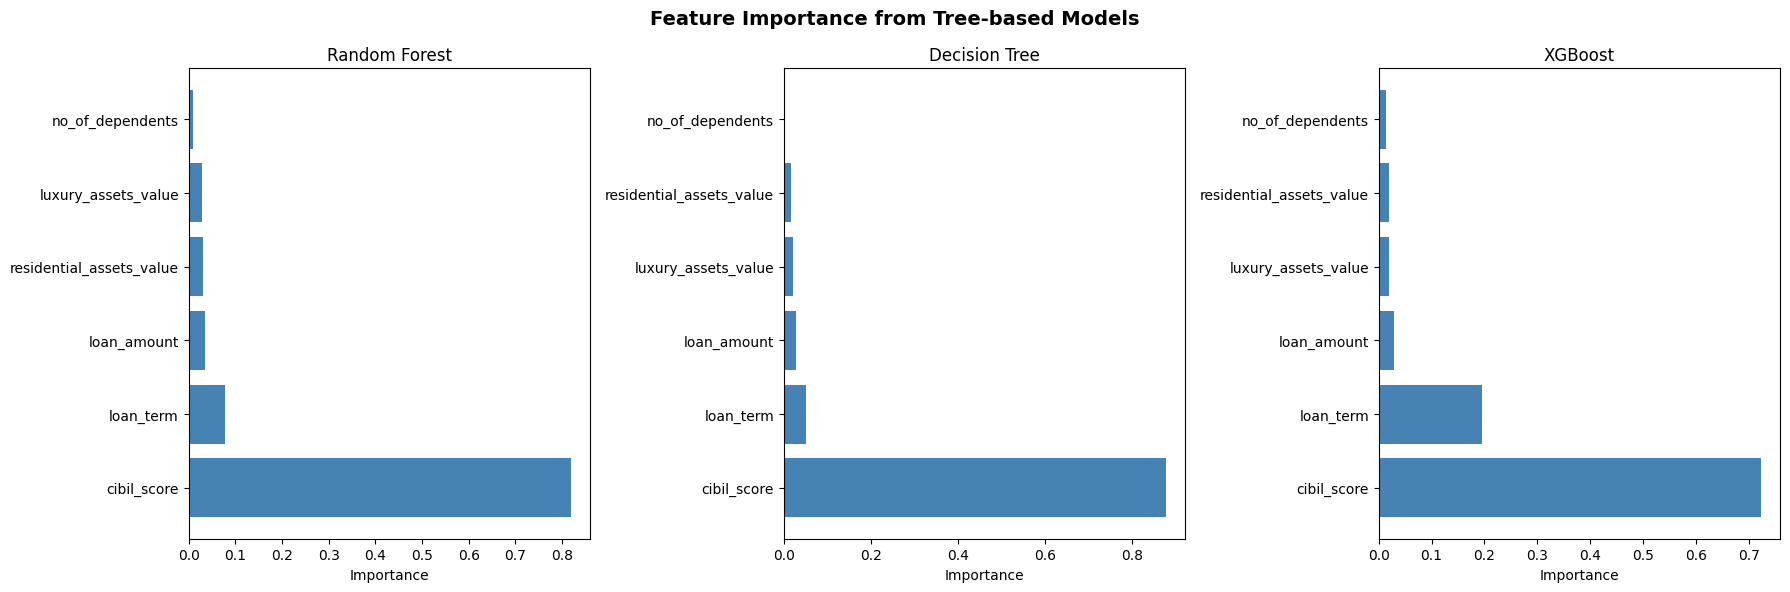

In [48]:

feature_names = X_train.columns


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Feature Importance from Tree-based Models', fontsize=14, fontweight='bold')

tree_models = [
    ('Random Forest', all_results['Random Forest']['Best Model']),
    ('Decision Tree', all_results['Decision Tree']['Best Model']),
    ('XGBoost', all_results['XGBoost']['Best Model'])
]

for idx, (name, model) in enumerate(tree_models):
    
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_

        top_idx = np.argsort(importances)[-10:]
        top_importances = importances[top_idx]
        top_feature_names = feature_names[top_idx]   
        
        ax = axes[idx]
        ax.barh(range(len(top_importances)), top_importances, color='steelblue')

        ax.set_yticks(range(len(top_importances)))
        ax.set_yticklabels(top_feature_names)  

        ax.set_xlabel('Importance')
        ax.set_title(name)
        ax.invert_yaxis()  

plt.tight_layout()
plt.show()


<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
<font face="B Nazanin" size="5">

28. به سوالات زیر پاسخ دهید.
- چرا هر سه مدل درختی (Decision Tree، Random Forest، XGBoost) مهم‌ترین ویژگی را یک ویژگی به خصوص  تشخیص داده‌اند؟
-  چرا اهمیت ویژگی‌ها در Random Forest نسبت به Decision Tree کمی «صاف‌تر» است؟
- اگر آسیب‌پذیری مدل به مهمترین ویژگی زیاد باشد چه خطر احتمالی وجود دارد؟
- اگر بخواهیم بفهمیم سایر فیچرها واقعاً بی‌اهمیت‌اند یا فقط به خاطر dominance دیده نمی‌شوند، چه کاری باید بکنیم؟
در سلول بعدی یک روش را انتخاب کرده و مساله را بررسی کنید. 
- اگر بخواهیم dominance را کاهش دهیم (تا سایر ویژگی‌ها هم فرصت دیده شدن پیدا کنند) چه‌کار می‌کنیم؟


<div dir=rtl>


**۱.** هر سه مدل **`cibil_score`** را مهم‌ترین ویژگی تشخیص داده‌اند. این با تحلیل‌های قبلی هم‌خوان است: ضریب همبستگی پیرسون با هدف 0.77 و MI حدود 0.505 بود. امتیاز اعتباری (CIBIL) مستقیماً وضعیت بازپرداخت وام را منعکس می‌کند، بنابراین منطقی است که درخت‌ها اول روی آن تقسیم کنند.

**۲.** Random Forest صدها درخت مستقل روی نمونه‌ها و ویژگی‌های مختلف می‌سازد و اهمیت را میانگین می‌گیرد؛ بنابراین توزیع importance صاف‌تر و پایدارتر از یک Decision Tree تکی است که ممکن است چند ویژگی را با اختلاف شدید از هم جدا کند.

**۳.** اگر مدل بیش‌ازحد به `cibil_score` وابسته باشد، با تغییر یا خطا در این ویژگی (مثلاً گزارش نادرست) عملکرد شدیداً افت می‌کند. همچنین مدل ممکن است روابط واقعی میان سایر ویژگی‌ها را نادیده بگیرد.

**۴.** روش **Permutation Importance** را انتخاب می‌کنیم: مقادیر `cibil_score` را به‌صورت تصادفی shuffle می‌کنیم و افت F1 را می‌سنجیم. اگر F1 زیاد افت کند، ویژگی واقعاً مهم است. سپس همین کار را برای سایر ویژگی‌ها تکرار می‌کنیم تا ببینیم آیا واقعاً بی‌اهمیت‌اند یا فقط در سایه `cibil_score` دیده نمی‌شوند.

**۵.** می‌توان `cibil_score` را موقتاً حذف و مدل را دوباره آموزش داد، از `max_features` کوچک‌تر در Random Forest استفاده کرد، یا regularization قوی‌تر اعمال کرد تا درخت‌ها مجبور شوند از سایر ویژگی‌ها هم استفاده کنند.

</div>

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
<font face="B Nazanin" size="5">
۲۹.سوال نهایی مربوط به پروژه دوم:
</p>
با توجه به پروژه‌ای که انجام دادید، به نظر شما استفاده از مدل‌های یادگیری ماشین برای پیش‌بینی اعطای وام در بانک‌ها و مؤسسات مالی چقدر کاربردی و قابل اعتماد است؟
در پاسخ خود به موارد زیر بپردازید:
</p>
الف) مزایای استفاده از این مدل‌ها در سیستم بانکی را بیان کنید.
</p>
ب) معایب و چالش‌های احتمالی استفاده از این مدل‌ها را بررسی کنید .
</p>
ج) به نظر شما یک دیتاست مناسب برای آموزش چنین مدلی باید چه ویژگی‌هایی داشته باشد؟
</p>
د) آیا مدل آموزش‌داده‌شده در این پروژه را برای استفاده در یک سیستم واقعی پیشنهاد می‌کنید؟ چرا؟



<div dir=rtl>


**الف) مزایا:** خودکارسازی و سرعت بالا در ارزیابی درخواست وام، کاهش خطای انسانی، امکان تحلیل همزمان تعداد زیادی متقاضی، و استفاده از الگوهای پیچیده در داده که انسان به‌راحتی نمی‌بیند. همچنین مدل می‌تواند به‌صورت یکنواخت و بدون تعصب شخصی تصمیم بگیرد.

**ب) معایب و چالش‌ها:** وابستگی به کیفیت داده، خطر bias در داده‌های تاریخی، مشکل تفسیرپذیری (به‌خصوص مدل‌های پیچیده)، حساسیت به تغییر شرایط اقتصادی (Concept Drift)، و خطر اتکای بیش‌ازحد به مدل بدون نظارت انسانی. همچنین خطای FP (وام به بدحساب) و FN (رد خوش‌حساب) هر کدام هزینه جدی دارند.

**ج) ویژگی‌های دیتاست مناسب:** حجم کافی، کیفیت بالا و بدون missing زیاد، متنوع بودن متقاضیان، برچسب‌های دقیق (واقعاً بدحساب/خوش‌حساب بودن)، ویژگی‌های مرتبط (درآمد، سابقه اعتباری، دارایی، بدهی)، و به‌روز بودن داده‌ها.

**د)** برای **پروژه آموزشی** بله؛ **XGBOOST** با Test F1≈0.98 و بدون نشانه بیش‌برازش، مدل مناسبی است. اما برای **سیستم واقعی بانکی** به‌تنهایی پیشنهاد نمی‌شود، چون: (۱) دیتاست محدود و احتمالاً ساده‌شده است، (۲) وابستگی شدید به `cibil_score` خطر single point of failure دارد، (۳) نیاز به اعتبارسنجی روی داده زمانی جدید، پایش drift و بررسی عدالت و شفافیت تصمیمات وجود دارد. پیشنهاد می‌شود مدل به‌عنوان ابزار کمکی به کارشناسان بانکی ارائه شود، نه تصمیم‌گیر نهایی.

</div>